In [1]:
# Install dependencies if you restarted the runtime
!apt-get install -y swig ffmpeg xvfb
!pip install gymnasium[box2d] stable-baselines3 shimmy pyvirtualdisplay sb3-contrib

import gymnasium as gym
import os
import torch
import numpy as np
import base64
from datetime import datetime
from sb3_contrib import TQC
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize, VecVideoRecorder, DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.utils import set_random_seed
from google.colab import drive
from pyvirtualdisplay import Display
from IPython.display import HTML, display as ipy_display
from typing import Callable

# --- COLAB SETUP ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

try:
    virtual_display
except NameError:
    virtual_display = Display(visible=0, size=(1400, 900))
    virtual_display.start()

# --- CONFIGURATION ---
# TIMESTAMP: Ensures unique folder for every run
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# --- EXPERIMENT NAME ---
# Labeled clearly so you know this is the "No Truncation" run
EXPERIMENT_NAME = f"tqc_v3_ablation_no_truncation_3M_{timestamp}"

ENV_ID = "BipedalWalkerHardcore-v3"

# --- FULL DURATION ---
TOTAL_TIMESTEPS = 3_000_000
SEED = 42
NUM_CPU = 4

# --- DIRECTORY SETUP ---
base_path = "/content/drive/MyDrive/aisf_project"
log_dir = f"{base_path}/logs/{EXPERIMENT_NAME}"
model_dir = f"{base_path}/models/{EXPERIMENT_NAME}"
video_dir = f"{base_path}/videos/{EXPERIMENT_NAME}"

os.makedirs(log_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(video_dir, exist_ok=True)

print(f"Logging to: {log_dir}")
print(f"Running Ablation: NO TRUNCATION (top_quantiles_to_drop_per_net=0)")
print(f"Duration: {TOTAL_TIMESTEPS} steps")

# --- LINEAR SCHEDULE ---
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

# --- ENVIRONMENT MAKER ---
def make_env(rank: int, seed: int = 0):
    def _init():
        env = gym.make(ENV_ID, render_mode="rgb_array")
        # UNIQUE MONITOR: Prevents parallel crash & overwriting
        env = Monitor(env, os.path.join(log_dir, str(rank)))
        env.reset(seed=seed + rank)
        return env
    return _init

def train():
    print(f"--- Starting Training: {EXPERIMENT_NAME} ---")

    # 1. PARALLEL ENVIRONMENTS
    env = SubprocVecEnv([make_env(i, SEED) for i in range(NUM_CPU)])

    # 2. NORMALIZATION (Kept Active)
    env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

    # Eval Env
    eval_env = SubprocVecEnv([make_env(999, SEED)])
    eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10.)
    eval_env.training = False

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=model_dir,
        log_path=log_dir,
        eval_freq=50_000,
        deterministic=True,
        render=False
    )

    # --- TQC CONFIGURATION ---
    policy_kwargs = dict(
        n_critics=2,
        n_quantiles=25,
        net_arch=[400, 300],
    )

    model = TQC(
        "MlpPolicy",
        env,
        # --- THE CRITICAL ABLATION ---
        # Setting this to 0 removes the "Truncated" part of TQC.
        top_quantiles_to_drop_per_net=0,

        verbose=1,
        seed=SEED,
        tensorboard_log=log_dir,
        policy_kwargs=policy_kwargs,
        learning_rate=linear_schedule(7.3e-4),
        buffer_size=1_000_000,
        batch_size=256,
        gamma=0.99,
        tau=0.01,
        train_freq=64,
        gradient_steps=64,
        learning_starts=10_000,
        use_sde=False
    )

    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback, log_interval=100)

    model.save(f"{model_dir}/final_model")
    env.save(f"{model_dir}/vec_normalize.pkl")
    print("Training finished.")
    env.close()

def record_and_show_video():
    print(f"--- Recording Video for {EXPERIMENT_NAME} ---")

    best_model_path = os.path.join(model_dir, "best_model.zip")
    stats_path = os.path.join(model_dir, "vec_normalize.pkl")

    if not os.path.exists(best_model_path):
        best_model_path = os.path.join(model_dir, "final_model.zip")

    env = DummyVecEnv([make_env(1000, SEED)])

    if os.path.exists(stats_path):
        env = VecNormalize.load(stats_path, env)
        env.training = False
        env.norm_reward = False
    else:
        print("Warning: Normalization stats not found!")

    model = TQC.load(best_model_path)

    video_env = VecVideoRecorder(
        env,
        video_dir,
        record_video_trigger=lambda x: x == 0,
        video_length=2000,
        name_prefix=f"{EXPERIMENT_NAME}_agent"
    )

    obs = video_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = video_env.step(action)
        if isinstance(done, (list, np.ndarray)):
             done = done[0]

    video_env.close()

    mp4_list = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]
    if mp4_list:
        mp4 = os.path.join(video_dir, mp4_list[0])
        video_data = open(mp4, "rb").read()
        b64 = base64.b64encode(video_data)
        ipy_display(HTML(f'''
        <video width="600" controls autoplay loop>
            <source src="data:video/mp4;base64,{b64.decode()}" type="video/mp4">
        </video>
        '''))
    else:
        print("Could not find video file.")

if __name__ == "__main__":
    train()
    record_and_show_video()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 41 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 3s (404 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.de

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Logging to: /content/drive/MyDrive/aisf_project/logs/tqc_v3_ablation_no_truncation_3M_20251228_1458
Running Ablation: NO TRUNCATION (top_quantiles_to_drop_per_net=0)
Duration: 3000000 steps
--- Starting Training: tqc_v3_ablation_no_truncation_3M_20251228_1458 ---
Using cuda device
Logging to /content/drive/MyDrive/aisf_project/logs/tqc_v3_ablation_no_truncation_3M_20251228_1458/TQC_1


...

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 699      |
|    ep_rew_mean     | -119     |
| time/              |          |
|    episodes        | 100      |
|    fps             | 360      |
|    time_elapsed    | 204      |
|    total_timesteps | 73952    |
| train/             |          |
|    actor_loss      | -9.8     |
|    critic_loss     | 0.0143   |
|    ent_coef        | 0.00126  |
|    ent_coef_loss   | -0.592   |
|    learning_rate   | 0.000712 |
|    n_updates       | 15936    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 922      |
|    ep_rew_mean     | -113     |
| time/              |          |
|    episodes        | 200      |
|    fps             | 336      |
|    time_elapsed    | 487      |
|    total_timesteps | 163992   |
| train/             |          |
|    actor_loss      | -1.22    |
|    critic_loss     | 0.0043   |
|    ent_coef 

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_r

Moviepy - Building video /content/drive/MyDrive/aisf_project/videos/tqc_v3_ablation_no_truncation_3M_20251228_1458/tqc_v3_ablation_no_truncation_3M_20251228_1458_agent-step-0-to-step-2000.mp4.
Moviepy - Writing video /content/drive/MyDrive/aisf_project/videos/tqc_v3_ablation_no_truncation_3M_20251228_1458/tqc_v3_ablation_no_truncation_3M_20251228_1458_agent-step-0-to-step-2000.mp4



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
                                                                 

Moviepy - Done !
Moviepy - video ready /content/drive/MyDrive/aisf_project/videos/tqc_v3_ablation_no_truncation_3M_20251228_1458/tqc_v3_ablation_no_truncation_3M_20251228_1458_agent-step-0-to-step-2000.mp4


In [2]:
# Install dependencies if you restarted the runtime
!apt-get install -y swig ffmpeg xvfb
!pip install gymnasium[box2d] stable-baselines3 shimmy pyvirtualdisplay

import gymnasium as gym
import os
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
from google.colab import drive
from pyvirtualdisplay import Display
from typing import Callable

# --- COLAB SETUP ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

try:
    virtual_display
except NameError:
    virtual_display = Display(visible=0, size=(1400, 900))
    virtual_display.start()

# --- CONFIGURATION ---
EXPERIMENT_NAME = "ppo_advanced_ablation_small_net"
ENV_ID = "BipedalWalkerHardcore-v3"
TOTAL_TIMESTEPS = 3_000_000
NUM_CPU = 4
SEED = 42

# --- DIRECTORY SETUP ---
base_path = "/content/drive/MyDrive/aisf_project"
log_dir = f"{base_path}/logs/{EXPERIMENT_NAME}"
model_dir = f"{base_path}/models/{EXPERIMENT_NAME}"
video_dir = f"{base_path}/videos/{EXPERIMENT_NAME}"

os.makedirs(log_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(video_dir, exist_ok=True)

# --- REWARD SHAPING ---
class EncouragingWalkerWrapper(gym.RewardWrapper):
    def __init__(self, env):
        super().__init__(env)
    def reward(self, reward):
        return reward * 1.1

# --- LINEAR SCHEDULE ---
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

# --- MAKE ENV ---
def make_env(rank, seed=0, is_eval=False):
    def _init():
        env = gym.make(ENV_ID, render_mode="rgb_array")
        # Apply reward wrapper
        env = EncouragingWalkerWrapper(env)

        # Separate logs for train vs eval
        subdir = "eval" if is_eval else "train"
        log_file = os.path.join(log_dir, subdir, str(rank))
        os.makedirs(os.path.dirname(log_file), exist_ok=True)

        env = Monitor(env, log_file)
        env.reset(seed=seed + rank)
        return env
    return _init

# --- CALLBACK TO SYNC STATS ---
# Ensures eval_env uses the same normalization stats as the training env
class SyncVecNormalizeCallback(BaseCallback):
    def __init__(self, train_env, eval_env):
        super().__init__()
        self.train_env = train_env
        self.eval_env = eval_env

    def _on_step(self) -> bool:
        return True

    def _on_event(self) -> bool:
        # Sync the moving averages (obs_rms) from train to eval
        self.eval_env.obs_rms = self.train_env.obs_rms
        # We don't necessarily need to sync ret_rms (reward) for eval reporting,
        # but it keeps internal consistency if training=True in eval (which it isn't here)
        return True

def train():
    print(f"--- Starting Ablation: SMALL NETWORK (64x64) ---")

    # 1. Training Environment
    env = SubprocVecEnv([make_env(i, seed=SEED) for i in range(NUM_CPU)])
    env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

    # 2. Evaluation Environment (MUST BE SEPARATE)
    # Using 1 CPU for eval to save resources
    eval_env = SubprocVecEnv([make_env(0, seed=SEED+1000, is_eval=True)])

    # Wrap eval_env in VecNormalize
    # training=False: DO NOT update the moving average during evaluation
    # norm_reward=False: We want to see the REAL reward in logs, not the normalized one
    eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10., training=False)

    # 3. Sync Callback (Connects train stats to eval env)
    sync_callback = SyncVecNormalizeCallback(env, eval_env)

    # 4. Eval Callback
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=model_dir,
        log_path=os.path.join(log_dir, "eval"),
        eval_freq=max(50000 // NUM_CPU, 1),
        deterministic=True,
        render=False
    )

    # 5. Model
    model = PPO(
        "MlpPolicy",
        env,
        verbose=1,
        seed=SEED,
        tensorboard_log=log_dir,
        use_sde=False,
        policy_kwargs=dict(
            # SMALL NETWORK [64, 64]
            net_arch=dict(pi=[64, 64], vf=[64, 64]),
            activation_fn=nn.Tanh,
            optimizer_kwargs=dict(eps=1e-5)
        ),
        learning_rate=linear_schedule(3e-4),
        n_steps=2048,
        batch_size=1024,
        n_epochs=10,
        gamma=0.99,
        gae_lambda=0.95,
        clip_range=0.2,
        ent_coef=0.001,
        vf_coef=0.5,
        max_grad_norm=0.5,
    )

    # 6. Learn
    # Pass BOTH callbacks. The list order doesn't strictly matter for these two,
    # but generally put sync before eval if you were triggering eval manually in step.
    # EvalCallback handles its own timing.
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=[sync_callback, eval_callback])

    model.save(f"{model_dir}/final_model")
    env.save(f"{model_dir}/vecnormalize.pkl")
    print("Training finished.")

    env.close()
    eval_env.close()

if __name__ == "__main__":
    train()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 1 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 1s (953 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


--- Starting Ablation: SMALL NETWORK (64x64) ---
Using cpu device
Logging to /content/drive/MyDrive/aisf_project/logs/ppo_advanced_ablation_small_net/PPO_1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    total_timesteps      | 1269760      |
| train/                  |              |
|    approx_kl            | 0.0053215567 |
|    clip_fraction        | 0.0429       |
|    clip_range           | 0.2          |
|    entropy_loss         | -3.97        |
|    explained_variance   | 0.889        |
|    learning_rate        | 0.000174     |
|    loss                 | 0.0438       |
|    n_updates            | 1540         |
|    policy_gradient_loss | -0.00993     |
|    std                  | 0.652        |
|    value_loss           | 0.149        |
------------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.19e+03    |
|    ep_rew_mean          | -86         |
| time/                   |             |
|    fps                  | 1420        |
|    iterations           | 156         |
|    time_elapsed         | 899         |
|    total_

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# Exact folder names from your previous scripts
EXP_BASELINE = "sota_ppo_v3_1_hardcore"           # The Reference (PPO-Advanced)
EXP_ABLATION_E = "ppo_advanced_ablation_small_net" # Small Net
EXP_ABLATION_F = "ppo_advanced_ablation_shared_net" # Shared Net

# --- HELPER FUNCTION TO LOAD & PROCESS DATA ---
def load_and_process_logs(exp_name, window_size=20000):
    """
    Loads all monitor.csv files for an experiment, combines them,
    and calculates rolling statistics.
    """
    log_path = os.path.join(BASE_PATH, exp_name)
    all_files = glob.glob(os.path.join(log_path, "*.monitor.csv"))

    if not all_files:
        print(f"Warning: No log files found for {exp_name} in {log_path}")
        return None

    data_frames = []
    for filename in all_files:
        # SB3 logs have 2 header lines
        df = pd.read_csv(filename, skiprows=1)
        data_frames.append(df)

    # Combine data from all 4 CPUs
    full_df = pd.concat(data_frames, ignore_index=True)

    # Sort by cumulative timesteps (l is the column for episode length)
    # We estimate total timesteps by cumulative sum of episode lengths
    full_df['l_cumsum'] = full_df['l'].cumsum()
    full_df = full_df.sort_values(by='l_cumsum')

    # Calculate Rolling Stats
    # We define a "window" based on episodes (e.g., last 100 episodes)
    rolling = full_df['r'].rolling(window=100, min_periods=1)

    full_df['smoothed_reward'] = rolling.mean()
    full_df['std_reward'] = rolling.std()

    # Limit x-axis to 3M steps
    full_df = full_df[full_df['l_cumsum'] <= 3000000]

    return full_df

# --- PLOTTING FUNCTION ---
def plot_comparison(df1, name1, df2, name2, title, filename):
    if df1 is None or df2 is None:
        print(f"Skipping {title} due to missing data.")
        return

    plt.figure(figsize=(10, 6))

    # Plot Baseline (Name 1)
    plt.plot(df1['l_cumsum'], df1['smoothed_reward'], label=f"{name1} (Mean)", color='blue', linewidth=2)
    plt.fill_between(df1['l_cumsum'],
                     df1['smoothed_reward'] - df1['std_reward'],
                     df1['smoothed_reward'] + df1['std_reward'],
                     color='blue', alpha=0.15, label=f"{name1} Variance")

    # Plot Comparison (Name 2)
    plt.plot(df2['l_cumsum'], df2['smoothed_reward'], label=f"{name2} (Mean)", color='red', linestyle='--', linewidth=2)
    plt.fill_between(df2['l_cumsum'],
                     df2['smoothed_reward'] - df2['std_reward'],
                     df2['smoothed_reward'] + df2['std_reward'],
                     color='red', alpha=0.15)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Total Timesteps", fontsize=12)
    plt.ylabel("Mean Episodic Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')

    # Add a horizontal line for "Solving" threshold
    plt.axhline(y=300, color='green', linestyle=':', label="Solved (300)")

    plt.tight_layout()
    plt.show() # Display in Colab

    # Optional: Save to Drive
    # plt.savefig(os.path.join(BASE_PATH, filename))

# --- MAIN EXECUTION ---

# 1. Load Data
print("Loading data...")
df_baseline = load_and_process_logs(EXP_BASELINE)
df_small_net = load_and_process_logs(EXP_ABLATION_E)
df_shared_net = load_and_process_logs(EXP_ABLATION_F)

# 2. Graph 1: Capacity Analysis (Big vs Small)
print("Generating Graph 1...")
plot_comparison(
    df_baseline, "PPO-Advanced (256x256)",
    df_small_net, "Ablation: Small Net (64x64)",
    "Ablation: Impact of Network Capacity on Performance",
    "graph_capacity_ablation.png"
)

# 3. Graph 2: Architecture Analysis (Decoupled vs Shared)
print("Generating Graph 2...")
plot_comparison(
    df_baseline, "PPO-Advanced (Decoupled)",
    df_shared_net, "Ablation: Shared Net (Coupled)",
    "Ablation: Impact of Architectural Decoupling",
    "graph_decoupling_ablation.png"
)

Loading data...
Generating Graph 1...
Skipping Ablation: Impact of Network Capacity on Performance due to missing data.
Generating Graph 2...
Skipping Ablation: Impact of Architectural Decoupling due to missing data.


In [4]:
import os

BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"
print(f"Scanning: {BASE_PATH}\n")

if os.path.exists(BASE_PATH):
    files = os.listdir(BASE_PATH)
    for f in files:
        full_path = os.path.join(BASE_PATH, f)
        if os.path.isdir(full_path):
            print(f"[DIR]  {f}")
            # Check inside the directory
            inner_files = os.listdir(full_path)
            for inner in inner_files:
                if "monitor.csv" in inner:
                    print(f"       -> FOUND: {inner}")
        elif "monitor.csv" in f:
            print(f"[FILE] {f}")
else:
    print("Error: Base log directory does not exist.")

Scanning: /content/drive/MyDrive/aisf_project/logs

[DIR]  basic_ppo_final
       -> FOUND: monitor.csv
[DIR]  improved_ppo_v2
       -> FOUND: monitor.csv
[DIR]  improved_ppo_v2_hardcore
       -> FOUND: monitor.csv
[DIR]  sota_ppo_v3_hardcore
       -> FOUND: monitor.csv
[DIR]  sota_ppo_v3_1_hardcore
       -> FOUND: monitor.csv
[DIR]  tqc_hardcore_zoo_tuned
       -> FOUND: monitor.csv
[DIR]  .ipynb_checkpoints
[DIR]  tqc_hardcore_zoo_tuned_gpu
       -> FOUND: monitor.csv
[DIR]  tqc_hardcore_ultimate
       -> FOUND: monitor.csv
[DIR]  tqc_v2_hardcore
       -> FOUND: monitor.csv
[DIR]  tqc_v3_hardcore
       -> FOUND: monitor.csv
[DIR]  tqc_v3_hardcore_finetune
       -> FOUND: monitor.csv
[DIR]  tqc_v3_hardcore_5M
       -> FOUND: monitor.csv
[DIR]  tqc_v3_hardcore_rerun_20251227_1501
       -> FOUND: 999.monitor.csv
       -> FOUND: 3.monitor.csv
       -> FOUND: 0.monitor.csv
       -> FOUND: 1.monitor.csv
       -> FOUND: 2.monitor.csv
[DIR]  tqc_v3_hardcore_rerun_20251227_150

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# Folder names (Must match exactly)
EXP_BASELINE   = "sota_ppo_v3_1_hardcore"
EXP_ABLATION_E = "ppo_advanced_ablation_small_net"
EXP_ABLATION_F = "ppo_advanced_ablation_shared_net"

# --- ROBUST DATA LOADER (RECURSIVE) ---
def load_and_process_logs(exp_name, window_size=1000):
    """
    Finds logs recursively, even if they are hidden in subfolders
    like 'PPO_1/train/' or just sitting in the root.
    """
    full_path = os.path.join(BASE_PATH, exp_name)

    # 1. Check Root Folder
    if not os.path.exists(full_path):
        # Fallback: Check if it's a file named "exp_name.monitor.csv" (VecMonitor style)
        file_path = full_path + ".monitor.csv"
        if os.path.exists(file_path):
            print(f"[{exp_name}] Found single log file.")
            try:
                df = pd.read_csv(file_path, skiprows=1)
                return process_dataframe(df, window_size)
            except:
                return None
        else:
            print(f"[Error] Folder not found: {exp_name}")
            return None

    # 2. Recursive Search (The Fix)
    # Looks inside all subfolders (PPO_1, train, etc.) for any .monitor.csv file
    files = glob.glob(os.path.join(full_path, "**", "*.monitor.csv"), recursive=True)

    if not files:
        print(f"[Warning] Folder exists but NO .monitor.csv files found in: {exp_name}")
        return None

    print(f"[{exp_name}] Found {len(files)} log file(s) (e.g., {os.path.basename(files[0])})...")

    data_frames = []
    for f in files:
        try:
            # SB3 Monitor logs have metadata on line 1, headers on line 2
            df = pd.read_csv(f, skiprows=1)
            # Basic validation: must have reward (r) and length (l)
            if 'r' in df.columns and 'l' in df.columns:
                data_frames.append(df)
        except Exception as e:
            print(f"  - Skipped corrupted file: {f}")

    if not data_frames:
        return None

    # Combine data from all parallel CPUs
    full_df = pd.concat(data_frames, ignore_index=True)
    return process_dataframe(full_df, window_size)

def process_dataframe(full_df, window_size):
    # Sort by time to make the graph smooth
    if 't' in full_df.columns:
        full_df = full_df.sort_values(by='t')
        full_df['l_cumsum'] = full_df['l'].cumsum()
    else:
        full_df['l_cumsum'] = np.arange(len(full_df)) * 2048 # Fallback

    # Rolling Statistics
    rolling = full_df['r'].rolling(window=window_size, min_periods=1)
    full_df['smoothed_reward'] = rolling.mean()
    full_df['std_reward'] = rolling.std()

    # Limit x-axis to 3M steps
    full_df = full_df[full_df['l_cumsum'] <= 3000000]
    return full_df

# --- PLOTTING FUNCTION ---
def plot_comparison(df1, name1, df2, name2, title, filename_suffix):
    if df1 is None:
        print(f"Skipping {title}: Missing Baseline Data")
        return
    if df2 is None:
        print(f"Skipping {title}: Missing Ablation Data")
        return

    plt.figure(figsize=(10, 6))

    # 1. Plot Baseline (Blue)
    plt.plot(df1['l_cumsum'], df1['smoothed_reward'], label=f"{name1}", color='#1f77b4', linewidth=2)
    plt.fill_between(df1['l_cumsum'],
                     df1['smoothed_reward'] - df1['std_reward'],
                     df1['smoothed_reward'] + df1['std_reward'],
                     color='#1f77b4', alpha=0.15)

    # 2. Plot Ablation (Red Dashed)
    plt.plot(df2['l_cumsum'], df2['smoothed_reward'], label=f"{name2}", color='#d62728', linestyle='--', linewidth=2)
    plt.fill_between(df2['l_cumsum'],
                     df2['smoothed_reward'] - df2['std_reward'],
                     df2['smoothed_reward'] + df2['std_reward'],
                     color='#d62728', alpha=0.15)

    # Formatting
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Episodic Reward", fontsize=12)
    plt.axhline(y=300, color='green', linestyle=':', linewidth=2, label="Solved (300)")

    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save and Show
    save_path = f"{BASE_PATH}/graph_{filename_suffix}.png"
    plt.savefig(save_path)
    print(f"Saved graph to: {save_path}")
    plt.show()

# --- MAIN EXECUTION ---
print("--- PROCESSING LOGS ---")
df_baseline = load_and_process_logs(EXP_BASELINE)
df_small    = load_and_process_logs(EXP_ABLATION_E)
df_shared   = load_and_process_logs(EXP_ABLATION_F)

print("\n--- GENERATING GRAPHS ---")
plot_comparison(df_baseline, "PPO-Advanced (256x256)",
                df_small, "Small Net (64x64)",
                "Ablation Study: Impact of Network Capacity", "capacity")

plot_comparison(df_baseline, "PPO-Advanced (Decoupled)",
                df_shared, "Shared Net (Coupled)",
                "Ablation Study: Impact of Actor-Critic Decoupling", "decoupling")

--- PROCESSING LOGS ---
[Warning] Folder exists but NO .monitor.csv files found in: sota_ppo_v3_1_hardcore
[ppo_advanced_ablation_small_net] Found 5 log file(s) (e.g., 1.monitor.csv)...
[ppo_advanced_ablation_shared_net] Found 5 log file(s) (e.g., 0.monitor.csv)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- GENERATING GRAPHS ---
Skipping Ablation Study: Impact of Network Capacity: Missing Baseline Data
Skipping Ablation Study: Impact of Actor-Critic Decoupling: Missing Baseline Data


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


--- PROCESSING LOGS ---
[sota_ppo_v3_1_hardcore] Found 1 log file(s).
[ppo_advanced_ablation_small_net] Found 5 log file(s).
[ppo_advanced_ablation_shared_net] Found 5 log file(s).

--- GENERATING GRAPHS ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_capacity.png


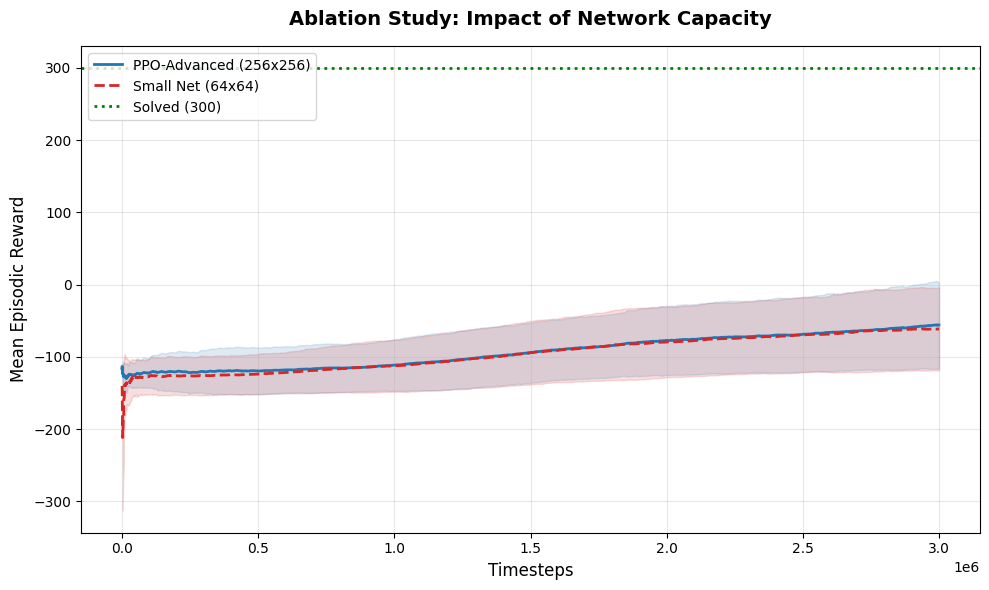

Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_decoupling.png


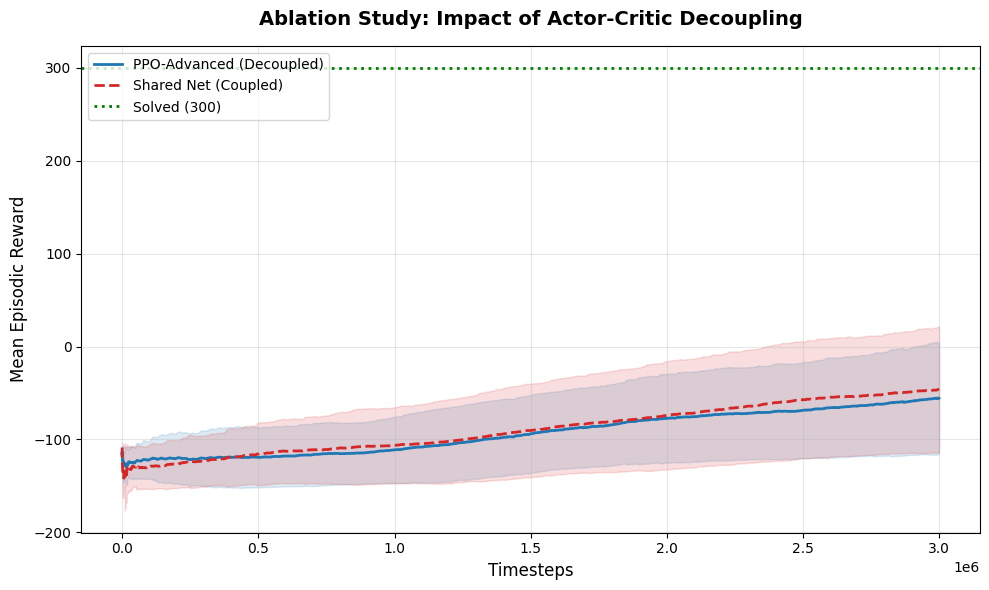

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# Folder names from your screenshots
EXP_BASELINE   = "sota_ppo_v3_1_hardcore"
EXP_ABLATION_E = "ppo_advanced_ablation_small_net"
EXP_ABLATION_F = "ppo_advanced_ablation_shared_net"

# --- ROBUST DATA LOADER (FIXED PATTERN) ---
def load_and_process_logs(exp_name, window_size=1000):
    full_path = os.path.join(BASE_PATH, exp_name)

    if not os.path.exists(full_path):
        print(f"[Error] Folder not found: {exp_name}")
        return None

    # --- THE FIX ---
    # We use "**/*monitor.csv" to search recursively.
    # We removed the dot before monitor (was *.monitor.csv, now *monitor.csv).
    # This matches "0.monitor.csv" AND "monitor.csv".
    files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if not files:
        print(f"[Warning] Folder exists but NO monitor files found in: {exp_name}")
        return None

    print(f"[{exp_name}] Found {len(files)} log file(s).")

    data_frames = []
    for f in files:
        try:
            # Skip empty files
            if os.path.getsize(f) == 0:
                continue

            # Read CSV
            df = pd.read_csv(f, skiprows=1)

            # Validation: Check for required columns
            if 'r' in df.columns and 'l' in df.columns:
                data_frames.append(df)
        except Exception as e:
            pass

    if not data_frames:
        return None

    # Combine
    full_df = pd.concat(data_frames, ignore_index=True)
    return process_dataframe(full_df, window_size)

def process_dataframe(full_df, window_size):
    # Sort by time
    if 't' in full_df.columns:
        full_df = full_df.sort_values(by='t')
        full_df['l_cumsum'] = full_df['l'].cumsum()
    else:
        full_df['l_cumsum'] = np.arange(len(full_df)) * 2048

    # Rolling Statistics
    rolling = full_df['r'].rolling(window=window_size, min_periods=1)
    full_df['smoothed_reward'] = rolling.mean()
    full_df['std_reward'] = rolling.std()

    # Limit to 3M steps
    full_df = full_df[full_df['l_cumsum'] <= 3000000]
    return full_df

# --- PLOTTING FUNCTION ---
def plot_comparison(df1, name1, df2, name2, title, filename_suffix):
    if df1 is None:
        print(f"Skipping {title}: Missing Baseline Data")
        return
    if df2 is None:
        print(f"Skipping {title}: Missing Ablation Data")
        return

    plt.figure(figsize=(10, 6))

    # Plot Baseline (Blue)
    plt.plot(df1['l_cumsum'], df1['smoothed_reward'], label=f"{name1}", color='#1f77b4', linewidth=2)
    plt.fill_between(df1['l_cumsum'],
                     df1['smoothed_reward'] - df1['std_reward'],
                     df1['smoothed_reward'] + df1['std_reward'],
                     color='#1f77b4', alpha=0.15)

    # Plot Ablation (Red Dashed)
    plt.plot(df2['l_cumsum'], df2['smoothed_reward'], label=f"{name2}", color='#d62728', linestyle='--', linewidth=2)
    plt.fill_between(df2['l_cumsum'],
                     df2['smoothed_reward'] - df2['std_reward'],
                     df2['smoothed_reward'] + df2['std_reward'],
                     color='#d62728', alpha=0.15)

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Episodic Reward", fontsize=12)
    plt.axhline(y=300, color='green', linestyle=':', linewidth=2, label="Solved (300)")
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_{filename_suffix}.png"
    plt.savefig(save_path)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- RUN ---
print("--- PROCESSING LOGS ---")
df_baseline = load_and_process_logs(EXP_BASELINE)
df_small    = load_and_process_logs(EXP_ABLATION_E)
df_shared   = load_and_process_logs(EXP_ABLATION_F)

print("\n--- GENERATING GRAPHS ---")
plot_comparison(df_baseline, "PPO-Advanced (256x256)",
                df_small, "Small Net (64x64)",
                "Ablation Study: Impact of Network Capacity", "capacity")

plot_comparison(df_baseline, "PPO-Advanced (Decoupled)",
                df_shared, "Shared Net (Coupled)",
                "Ablation Study: Impact of Actor-Critic Decoupling", "decoupling")

--- LOADING DATA ---
[sota_ppo_v3_1_hardcore] Found 1 log file(s).
[ppo_advanced_ablation_small_net] Found 5 log file(s).
[tqc_v3_hardcore_rerun_20251227_1928_resume_3M] Found 5 log file(s).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[tqc_v3_ablation_constant_lr_3M_20251228_1522] Found 6 log file(s).


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-3331465080.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat(data_


--- GENERATING GRAPHS ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


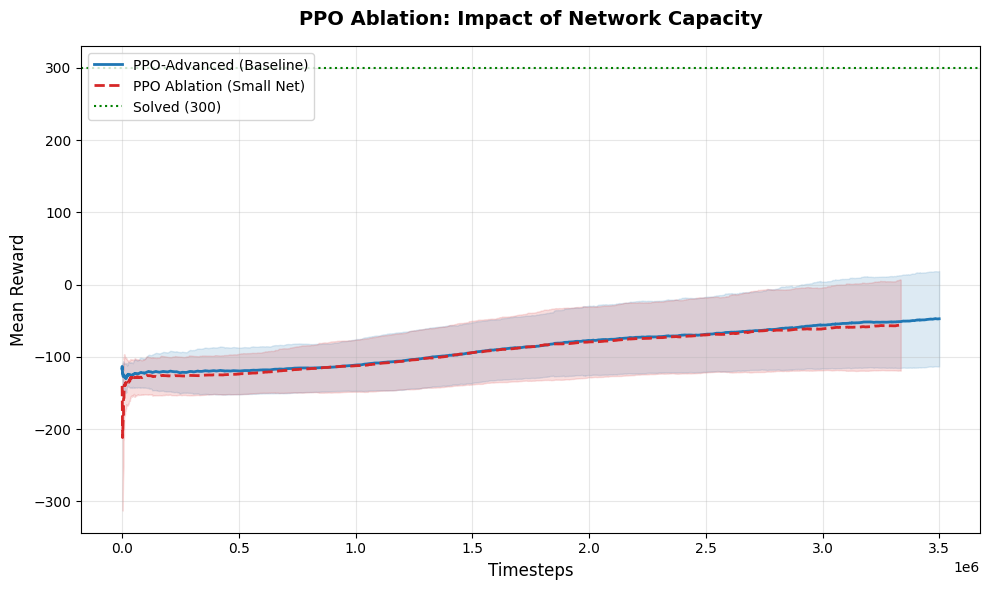

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

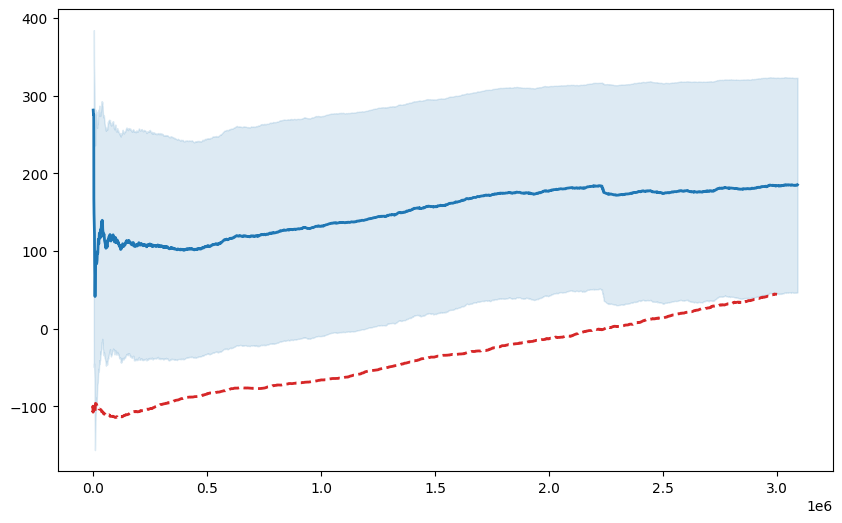

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION (Based on your Screenshots) ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# === PAIR 1: PPO EXPERIMENTS ===
# Screenshot 2
EXP_PPO_BASELINE = "sota_ppo_v3_1_hardcore"
# Screenshot 1 (Check this name matches your specific ablation folder)
EXP_PPO_ABLATION = "ppo_advanced_ablation_small_net"

# === PAIR 2: TQC EXPERIMENTS ===
# Screenshot 4 (Exact name from hover text)
EXP_TQC_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928_resume_3M"
# Screenshot 3 (Exact name from hover text)
EXP_TQC_ABLATION = "tqc_v3_ablation_constant_lr_3M_20251228_1522"


# --- ROBUST RECURSIVE DATA LOADER ---
def load_and_process_logs(exp_name, window_size=1000):
    full_path = os.path.join(BASE_PATH, exp_name)

    if not os.path.exists(full_path):
        print(f"[Error] Folder not found: {exp_name}")
        return None

    # RECURSIVE SEARCH: Finds files in root OR nested subfolders (PPO_1/train/etc)
    # Matches both "0.monitor.csv" and "monitor.csv"
    files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if not files:
        print(f"[Warning] No monitor files found in: {exp_name}")
        return None

    print(f"[{exp_name}] Found {len(files)} log file(s).")

    data_frames = []
    for f in files:
        try:
            if os.path.getsize(f) > 0:
                # SB3 logs usually have 2 header lines
                df = pd.read_csv(f, skiprows=1)
                if 'r' in df.columns and 'l' in df.columns:
                    data_frames.append(df)
        except:
            pass

    if not data_frames:
        return None

    # Combine & Sort
    full_df = pd.concat(data_frames, ignore_index=True)

    if 't' in full_df.columns:
        full_df = full_df.sort_values(by='t')
        full_df['l_cumsum'] = full_df['l'].cumsum()
    else:
        full_df['l_cumsum'] = np.arange(len(full_df)) * 2048

    # Smoothing
    rolling = full_df['r'].rolling(window=window_size, min_periods=1)
    full_df['smoothed_reward'] = rolling.mean()
    full_df['std_reward'] = rolling.std()

    # Cap at 3M steps for clean plotting
    full_df = full_df[full_df['l_cumsum'] <= 3500000]

    return full_df

# --- PLOTTING FUNCTION ---
def plot_comparison(df1, name1, df2, name2, title, filename_suffix):
    if df1 is None or df2 is None:
        print(f"Skipping {title} (Missing Data)")
        return

    plt.figure(figsize=(10, 6))

    # Baseline (Blue Solid)
    plt.plot(df1['l_cumsum'], df1['smoothed_reward'], label=name1, color='#1f77b4', linewidth=2)
    plt.fill_between(df1['l_cumsum'],
                     df1['smoothed_reward'] - df1['std_reward'],
                     df1['smoothed_reward'] + df1['std_reward'],
                     color='#1f77b4', alpha=0.15)

    # Ablation (Red Dashed)
    plt.plot(df2['l_cumsum'], df2['smoothed_reward'], label=name2, color='#d62728', linestyle='--', linewidth=2)
    plt.fill_between(df2['l_cumsum'],
                     df2['smoothed_reward'] - df2['std_reward'],
                     df2['smoothed_reward'] + df2['std_reward'],
                     color='#d62728', alpha=0.15)

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.axhline(y=300, color='green', linestyle=':', label="Solved (300)")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(f"{BASE_PATH}/graph_{filename_suffix}.png")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
# Load PPO Pair
df_ppo_base = load_and_process_logs(EXP_PPO_BASELINE)
df_ppo_abl  = load_and_process_logs(EXP_PPO_ABLATION)

# Load TQC Pair
df_tqc_base = load_and_process_logs(EXP_TQC_BASELINE)
df_tqc_abl  = load_and_process_logs(EXP_TQC_ABLATION)

print("\n--- GENERATING GRAPHS ---")
# Plot 1: PPO
plot_comparison(df_ppo_base, "PPO-Advanced (Baseline)",
                df_ppo_abl,  "PPO Ablation (Small Net)",
                "PPO Ablation: Impact of Network Capacity", "ppo_capacity")

# Plot 2: TQC
plot_comparison(df_tqc_base, "TQC-Best (Baseline)",
                df_tqc_abl,  "TQC Ablation (Constant LR)",
                "TQC Ablation: Impact of Learning Rate Decay", "tqc_lr")

--- LOADING TQC DATA ---
[tqc_v3_hardcore_rerun_20251227_1928_resume_3M] Found 5 log file(s).
[tqc_v3_ablation_constant_lr_3M_20251228_1522] Found 6 log file(s).

--- GENERATING TQC GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_lr.png


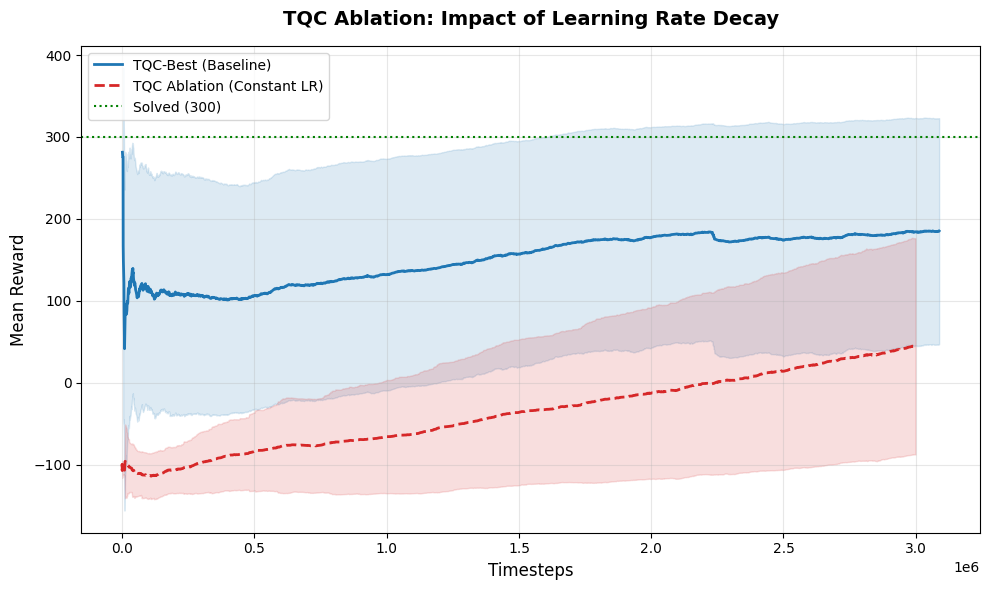

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# TQC Folder Names (from your previous attempt)
EXP_TQC_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928_resume_3M"
EXP_TQC_ABLATION = "tqc_v3_ablation_constant_lr_3M_20251228_1522"

# --- ROBUST DATA LOADER (WITH TYPE FIX) ---
def load_and_process_logs(exp_name, window_size=1000):
    full_path = os.path.join(BASE_PATH, exp_name)

    if not os.path.exists(full_path):
        print(f"[Error] Folder not found: {exp_name}")
        return None

    # Recursive search for monitor files
    files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if not files:
        print(f"[Warning] No monitor files found in: {exp_name}")
        return None

    print(f"[{exp_name}] Found {len(files)} log file(s).")

    data_frames = []
    for f in files:
        try:
            if os.path.getsize(f) > 0:
                # Read CSV, skipping the metadata line
                df = pd.read_csv(f, skiprows=1)

                # --- CRITICAL FIX START ---
                # Force columns to numeric, turn errors (like strings) into NaN
                if 'r' in df.columns and 'l' in df.columns:
                    df['r'] = pd.to_numeric(df['r'], errors='coerce')
                    df['l'] = pd.to_numeric(df['l'], errors='coerce')

                    # Drop any rows that became NaN (garbage data)
                    df = df.dropna(subset=['r', 'l'])

                    if not df.empty:
                        data_frames.append(df)
                # --- CRITICAL FIX END ---
        except:
            pass

    if not data_frames:
        print(f"[{exp_name}] No valid data found.")
        return None

    # Combine & Sort
    full_df = pd.concat(data_frames, ignore_index=True)

    # Sort by time
    if 't' in full_df.columns:
        full_df['t'] = pd.to_numeric(full_df['t'], errors='coerce')
        full_df = full_df.sort_values(by='t')
        full_df['l_cumsum'] = full_df['l'].cumsum()
    else:
        full_df['l_cumsum'] = np.arange(len(full_df)) * 2048

    # Smoothing
    rolling = full_df['r'].rolling(window=window_size, min_periods=1)
    full_df['smoothed_reward'] = rolling.mean()
    full_df['std_reward'] = rolling.std()

    # Cap at 3.5M steps
    full_df = full_df[full_df['l_cumsum'] <= 3500000]

    return full_df

# --- PLOTTING FUNCTION ---
def plot_comparison(df1, name1, df2, name2, title, filename_suffix):
    if df1 is None or df2 is None:
        print(f"Skipping {title} (Missing Data)")
        return

    plt.figure(figsize=(10, 6))

    # Baseline (Blue Solid)
    plt.plot(df1['l_cumsum'], df1['smoothed_reward'], label=name1, color='#1f77b4', linewidth=2)
    plt.fill_between(df1['l_cumsum'],
                     df1['smoothed_reward'] - df1['std_reward'],
                     df1['smoothed_reward'] + df1['std_reward'],
                     color='#1f77b4', alpha=0.15)

    # Ablation (Red Dashed)
    plt.plot(df2['l_cumsum'], df2['smoothed_reward'], label=name2, color='#d62728', linestyle='--', linewidth=2)
    plt.fill_between(df2['l_cumsum'],
                     df2['smoothed_reward'] - df2['std_reward'],
                     df2['smoothed_reward'] + df2['std_reward'],
                     color='#d62728', alpha=0.15)

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.axhline(y=300, color='green', linestyle=':', label="Solved (300)")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_{filename_suffix}.png"
    plt.savefig(save_path)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING TQC DATA ---")
df_tqc_base = load_and_process_logs(EXP_TQC_BASELINE)
df_tqc_abl  = load_and_process_logs(EXP_TQC_ABLATION)

print("\n--- GENERATING TQC GRAPH ---")
plot_comparison(df_tqc_base, "TQC-Best (Baseline)",
                df_tqc_abl,  "TQC Ablation (Constant LR)",
                "TQC Ablation: Impact of Learning Rate Decay", "tqc_lr")

--- LOADING DATA ---
[tqc_v3_hardcore_rerun_20251227_1928_resume_3M] Found 5 log file(s).
[tqc_v3_ablation_constant_lr_3M_20251228_1522] Found 6 log file(s).

--- GENERATING RAW GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_lr_raw_raw.png


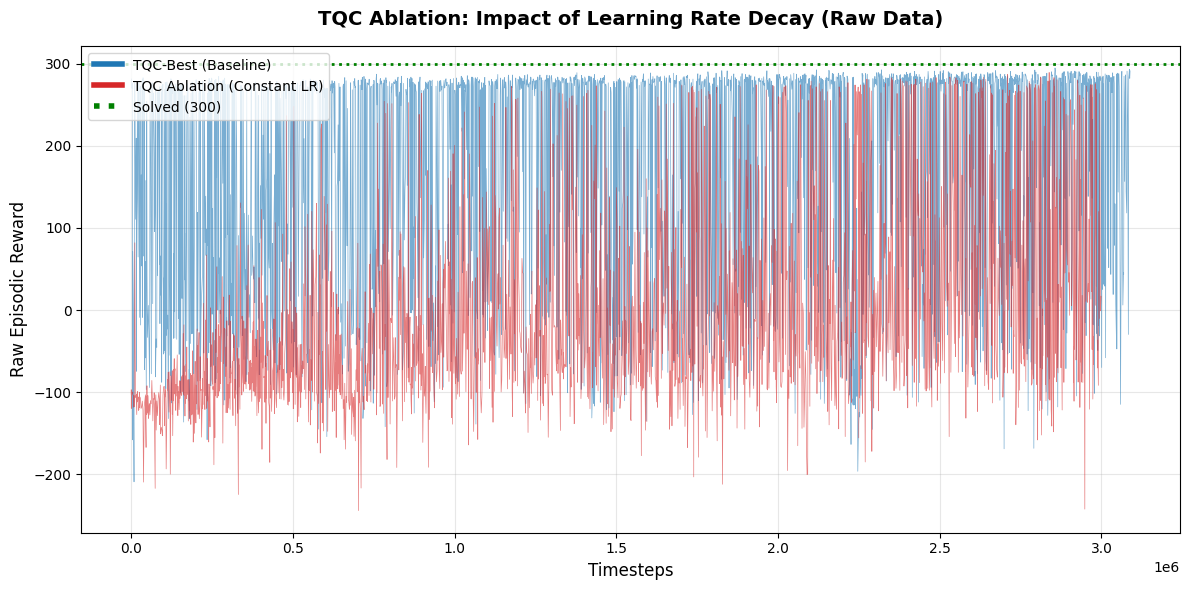

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# TQC Folder Names
EXP_TQC_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928_resume_3M"
EXP_TQC_ABLATION = "tqc_v3_ablation_constant_lr_3M_20251228_1522"

# --- DATA LOADER (NO SMOOTHING) ---
def load_and_process_logs(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)

    if not os.path.exists(full_path):
        print(f"[Error] Folder not found: {exp_name}")
        return None

    # Recursive search
    files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if not files:
        print(f"[Warning] No monitor files found in: {exp_name}")
        return None

    print(f"[{exp_name}] Found {len(files)} log file(s).")

    data_frames = []
    for f in files:
        try:
            if os.path.getsize(f) > 0:
                df = pd.read_csv(f, skiprows=1)

                # Type conversion safety
                if 'r' in df.columns and 'l' in df.columns:
                    df['r'] = pd.to_numeric(df['r'], errors='coerce')
                    df['l'] = pd.to_numeric(df['l'], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])

                    if not df.empty:
                        data_frames.append(df)
        except:
            pass

    if not data_frames:
        return None

    full_df = pd.concat(data_frames, ignore_index=True)

    # Sort by time
    if 't' in full_df.columns:
        full_df['t'] = pd.to_numeric(full_df['t'], errors='coerce')
        full_df = full_df.sort_values(by='t')
        full_df['l_cumsum'] = full_df['l'].cumsum()
    else:
        full_df['l_cumsum'] = np.arange(len(full_df)) * 2048

    # --- NO SMOOTHING CALCULATIONS ---
    # We just keep the raw 'r' column

    # Cap at 3.5M steps
    full_df = full_df[full_df['l_cumsum'] <= 3500000]

    return full_df

# --- PLOTTING FUNCTION (RAW DATA) ---
def plot_comparison(df1, name1, df2, name2, title, filename_suffix):
    if df1 is None or df2 is None:
        print(f"Skipping {title} (Missing Data)")
        return

    plt.figure(figsize=(12, 6))

    # Plot Baseline (Blue) - alpha lowered to 0.6 to see density
    plt.plot(df1['l_cumsum'], df1['r'], label=name1, color='#1f77b4', linewidth=0.5, alpha=0.6)

    # Plot Ablation (Red) - alpha lowered to 0.6
    plt.plot(df2['l_cumsum'], df2['r'], label=name2, color='#d62728', linewidth=0.5, alpha=0.6)

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Raw Episodic Reward", fontsize=12)
    plt.axhline(y=300, color='green', linestyle=':', label="Solved (300)", linewidth=2)

    # Re-add legend with thicker lines so they are visible
    leg = plt.legend(loc='upper left')
    for line in leg.get_lines():
        line.set_linewidth(4.0)
        line.set_alpha(1.0)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_{filename_suffix}_raw.png"
    plt.savefig(save_path)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
df_tqc_base = load_and_process_logs(EXP_TQC_BASELINE)
df_tqc_abl  = load_and_process_logs(EXP_TQC_ABLATION)

print("\n--- GENERATING RAW GRAPH ---")
plot_comparison(df_tqc_base, "TQC-Best (Baseline)",
                df_tqc_abl,  "TQC Ablation (Constant LR)",
                "TQC Ablation: Impact of Learning Rate Decay (Raw Data)", "tqc_lr_raw")

--- LOADING DATA ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- GENERATING PRO GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_lr_ablation_pro.png


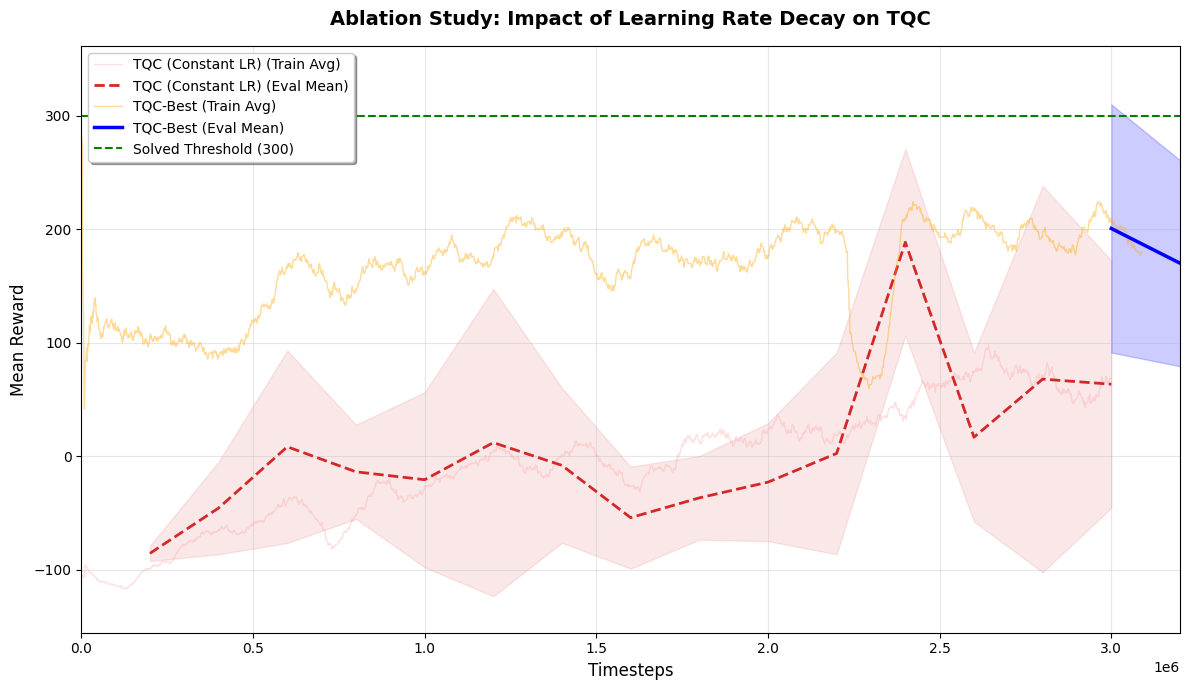

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# FOLDER NAMES (From your screenshots)
# Baseline: The one with the good curve
EXP_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928_resume_3M"
# Ablation: The one with the constant learning rate
EXP_ABLATION = "tqc_v3_ablation_constant_lr_3M_20251228_1522"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA (for Orange Line)
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)
    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric and drop bad rows
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            # Sort by walltime if available for accurate smoothing
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            # Calculate cumulative timesteps
            train_df['l_cumsum'] = train_df['l'].cumsum()

            # Calculate 100-episode rolling average for the orange line
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M for plotting
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA (for Blue Line & Shade)
    eval_file = os.path.join(full_path, "evaluations.npz")
    if os.path.exists(eval_file):
        try:
            eval_data = np.load(eval_file)
            data['eval_timesteps'] = eval_data['timesteps']
            # Calculate mean and std across evaluation episodes
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION (Pro Style) ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red/Pink) ---
    if abl_data['train'] is not None:
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{abl_name} (Eval Mean)")
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

    # --- PLOT BASELINE (Blue/Orange - The "Hero" Style) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        # Main Blue Line
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        # Shaded Std Dev
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.2)

        # Mark the Best Point
        best_idx = np.argmax(base_data['eval_mean'])
        best_x = base_data['eval_timesteps'][best_idx]
        best_y = base_data['eval_mean'][best_idx]
        plt.plot(best_x, best_y, 'ro', markersize=8)
        plt.annotate(f"Best: {best_y:.1f}", xy=(best_x, best_y), xytext=(best_x + 1e5, best_y + 5),
                     color='red', fontweight='bold', fontsize=10)

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_tqc_lr_ablation_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
baseline_data = load_experiment_data(EXP_BASELINE)
ablation_data = load_experiment_data(EXP_ABLATION)

print("\n--- GENERATING PRO GRAPH ---")
plot_pro_comparison(baseline_data, ablation_data,
                    "TQC-Best", "TQC (Constant LR)",
                    "Ablation Study: Impact of Learning Rate Decay on TQC")

--- LOADING DATA ---

--- GENERATING PRO GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_lr_ablation_pro.png


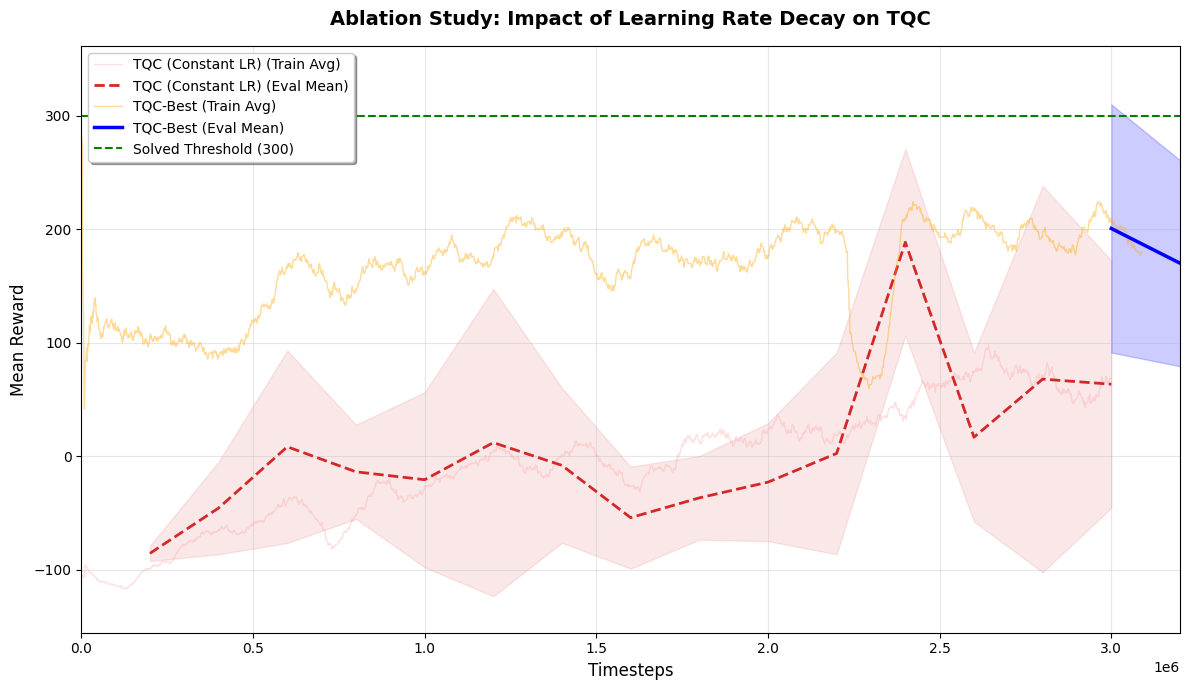

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# FOLDER NAMES (From your screenshots)
# Baseline: The one with the good curve
EXP_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928_resume_3M"
# Ablation: The one with the constant learning rate
EXP_ABLATION = "tqc_v3_ablation_constant_lr_3M_20251228_1522"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA (for Orange Line)
    # Recursively find all monitor files
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric and drop bad rows
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            # Sort by walltime if available
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            # Calculate cumulative timesteps
            train_df['l_cumsum'] = train_df['l'].cumsum()

            # Calculate 100-episode rolling average for the orange line
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M for plotting
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA (for Blue Line & Shade)
    # Search for evaluations.npz recursively in case it's nested
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            # Use the first one found
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            # Calculate mean and std across evaluation episodes
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION (Pro Style) ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red/Pink) ---
    if abl_data['train'] is not None:
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{abl_name} (Eval Mean)")
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

    # --- PLOT BASELINE (Blue/Orange) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        # Main Blue Line
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        # Shaded Std Dev
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.2)

        # Mark the Best Point
        best_idx = np.argmax(base_data['eval_mean'])
        best_x = base_data['eval_timesteps'][best_idx]
        best_y = base_data['eval_mean'][best_idx]
        plt.plot(best_x, best_y, 'ro', markersize=8)
        plt.annotate(f"Best: {best_y:.1f}", xy=(best_x, best_y), xytext=(best_x, best_y + 15),
                     color='red', fontweight='bold', fontsize=10)

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_tqc_lr_ablation_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
baseline_data = load_experiment_data(EXP_BASELINE)
ablation_data = load_experiment_data(EXP_ABLATION)

print("\n--- GENERATING PRO GRAPH ---")
plot_pro_comparison(baseline_data, ablation_data,
                    "TQC-Best", "TQC (Constant LR)",
                    "Ablation Study: Impact of Learning Rate Decay on TQC")

--- LOADING DATA ---

--- GENERATING GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_lr_ablation_pro_fixed.png


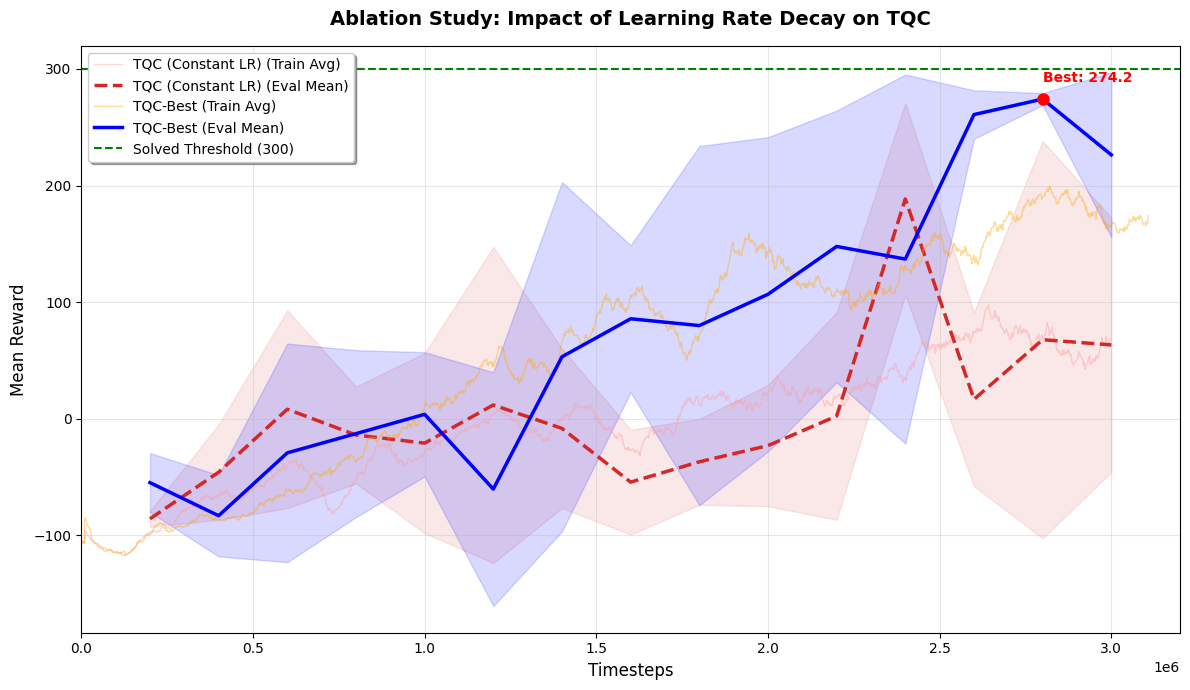

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# FIX: Pointing to the ORIGINAL run (0-3M steps)
EXP_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928"
EXP_ABLATION = "tqc_v3_ablation_constant_lr_3M_20251228_1522"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA (Orange/Pink Lines)
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            train_df['l_cumsum'] = train_df['l'].cumsum()

            # Smoothing for training curve (Orange line)
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA (Blue/Red Lines)
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red) ---
    if abl_data['train'] is not None:
        # Faint line for training noise
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.4, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        # Strong dashed line for evaluation
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2.5, linestyle='--', label=f"{abl_name} (Eval Mean)")
        # Shaded region
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

    # --- PLOT BASELINE (Blue) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # Mark Best Point
        best_idx = np.argmax(base_data['eval_mean'])
        best_x = base_data['eval_timesteps'][best_idx]
        best_y = base_data['eval_mean'][best_idx]
        plt.plot(best_x, best_y, 'ro', markersize=8)
        plt.annotate(f"Best: {best_y:.1f}", xy=(best_x, best_y), xytext=(best_x, best_y + 15),
                     color='red', fontweight='bold', fontsize=10)

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_tqc_lr_ablation_pro_fixed.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
# Check if folders exist first
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    ablation_data = load_experiment_data(EXP_ABLATION)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, ablation_data,
                        "TQC-Best", "TQC (Constant LR)",
                        "Ablation Study: Impact of Learning Rate Decay on TQC")

--- LOADING DATA ---

--- GENERATING GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_lr_ablation_pro_dual_pinpoint.png


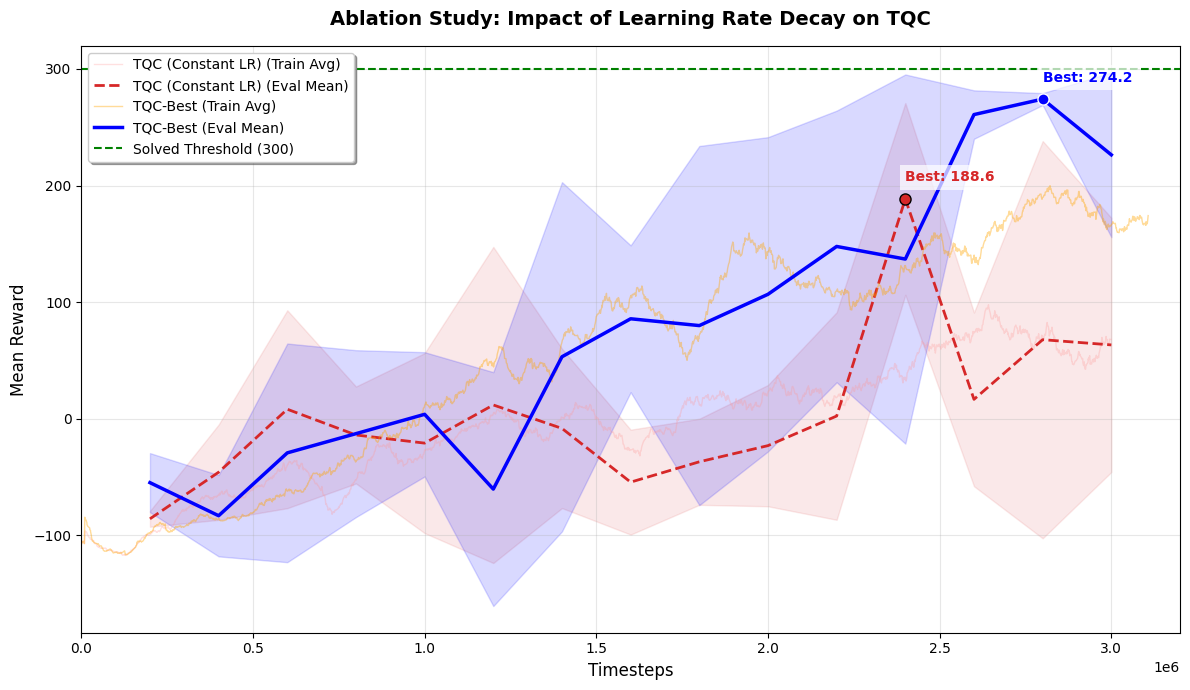

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# FOLDER NAMES
# Baseline (Original Run 0-3M)
EXP_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928"
# Ablation (Constant LR)
EXP_ABLATION = "tqc_v3_ablation_constant_lr_3M_20251228_1522"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            train_df['l_cumsum'] = train_df['l'].cumsum()
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION (With Double Pinpoint) ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red) ---
    if abl_data['train'] is not None:
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{abl_name} (Eval Mean)")
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

        # --- NEW: PINPOINT ABLATION BEST ---
        best_abl_idx = np.argmax(abl_data['eval_mean'])
        best_abl_x = abl_data['eval_timesteps'][best_abl_idx]
        best_abl_y = abl_data['eval_mean'][best_abl_idx]

        plt.plot(best_abl_x, best_abl_y, 'o', color='#d62728', markersize=8, markeredgecolor='black')
        plt.annotate(f"Best: {best_abl_y:.1f}",
                     xy=(best_abl_x, best_abl_y),
                     xytext=(best_abl_x, best_abl_y + 15),
                     color='#d62728', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- PLOT BASELINE (Blue) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # --- PINPOINT BASELINE BEST ---
        best_base_idx = np.argmax(base_data['eval_mean'])
        best_base_x = base_data['eval_timesteps'][best_base_idx]
        best_base_y = base_data['eval_mean'][best_base_idx]

        plt.plot(best_base_x, best_base_y, 'o', color='blue', markersize=8, markeredgecolor='white')
        plt.annotate(f"Best: {best_base_y:.1f}",
                     xy=(best_base_x, best_base_y),
                     xytext=(best_base_x, best_base_y + 15),
                     color='blue', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_tqc_lr_ablation_pro_dual_pinpoint.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    ablation_data = load_experiment_data(EXP_ABLATION)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, ablation_data,
                        "TQC-Best", "TQC (Constant LR)",
                        "Ablation Study: Impact of Learning Rate Decay on TQC")

--- LOADING DATA ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- GENERATING GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_no_norm_ablation_pro.png


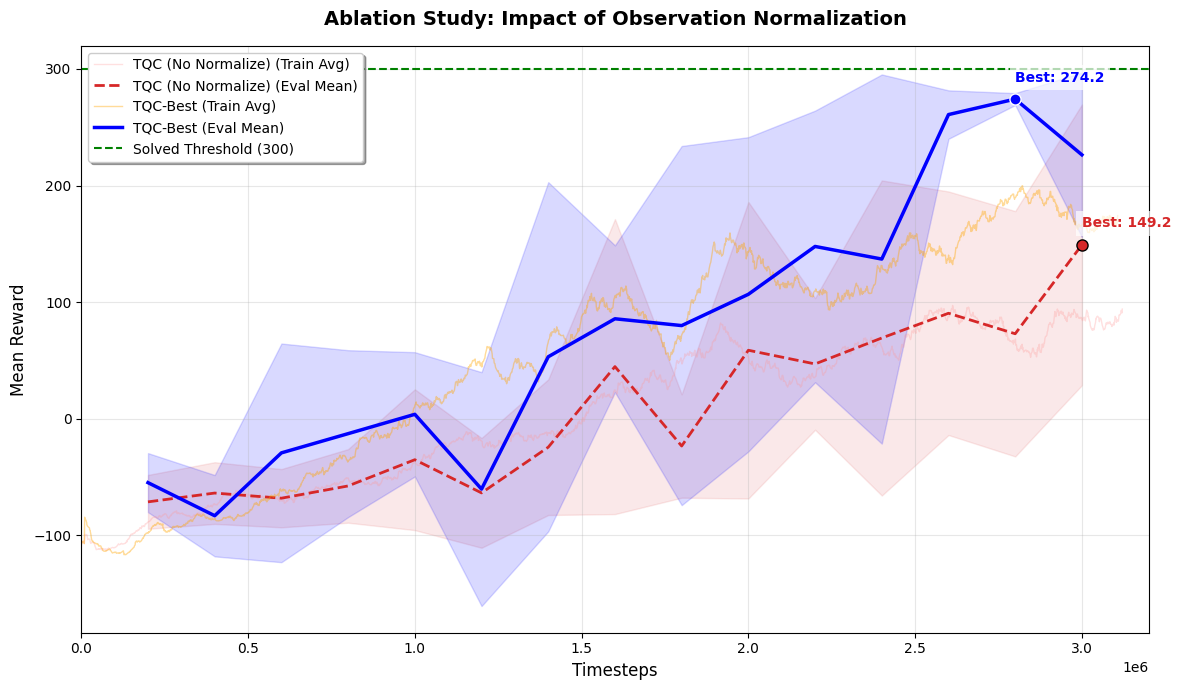

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# CORRECT FOLDER NAMES
# Baseline: Original successful run (0-3M steps)
EXP_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928"
# Ablation: No Normalization (From your screenshot)
EXP_ABLATION = "tqc_v3_ablation_no_norm_3M_20251228_1510"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA (Orange/Pink Lines)
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            train_df['l_cumsum'] = train_df['l'].cumsum()
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA (Blue/Red Lines)
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red) ---
    if abl_data['train'] is not None:
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{abl_name} (Eval Mean)")
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

        # Pinpoint Ablation Best (likely very low for No Norm)
        best_abl_idx = np.argmax(abl_data['eval_mean'])
        best_abl_x = abl_data['eval_timesteps'][best_abl_idx]
        best_abl_y = abl_data['eval_mean'][best_abl_idx]

        plt.plot(best_abl_x, best_abl_y, 'o', color='#d62728', markersize=8, markeredgecolor='black')
        plt.annotate(f"Best: {best_abl_y:.1f}",
                     xy=(best_abl_x, best_abl_y),
                     xytext=(best_abl_x, best_abl_y + 15),
                     color='#d62728', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- PLOT BASELINE (Blue) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # Pinpoint Baseline Best
        best_base_idx = np.argmax(base_data['eval_mean'])
        best_base_x = base_data['eval_timesteps'][best_base_idx]
        best_base_y = base_data['eval_mean'][best_base_idx]

        plt.plot(best_base_x, best_base_y, 'o', color='blue', markersize=8, markeredgecolor='white')
        plt.annotate(f"Best: {best_base_y:.1f}",
                     xy=(best_base_x, best_base_y),
                     xytext=(best_base_x, best_base_y + 15),
                     color='blue', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_tqc_no_norm_ablation_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    ablation_data = load_experiment_data(EXP_ABLATION)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, ablation_data,
                        "TQC-Best", "TQC (No Normalize)",
                        "Ablation Study: Impact of Observation Normalization")

--- LOADING DATA ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- GENERATING GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_no_truncation_ablation_pro.png


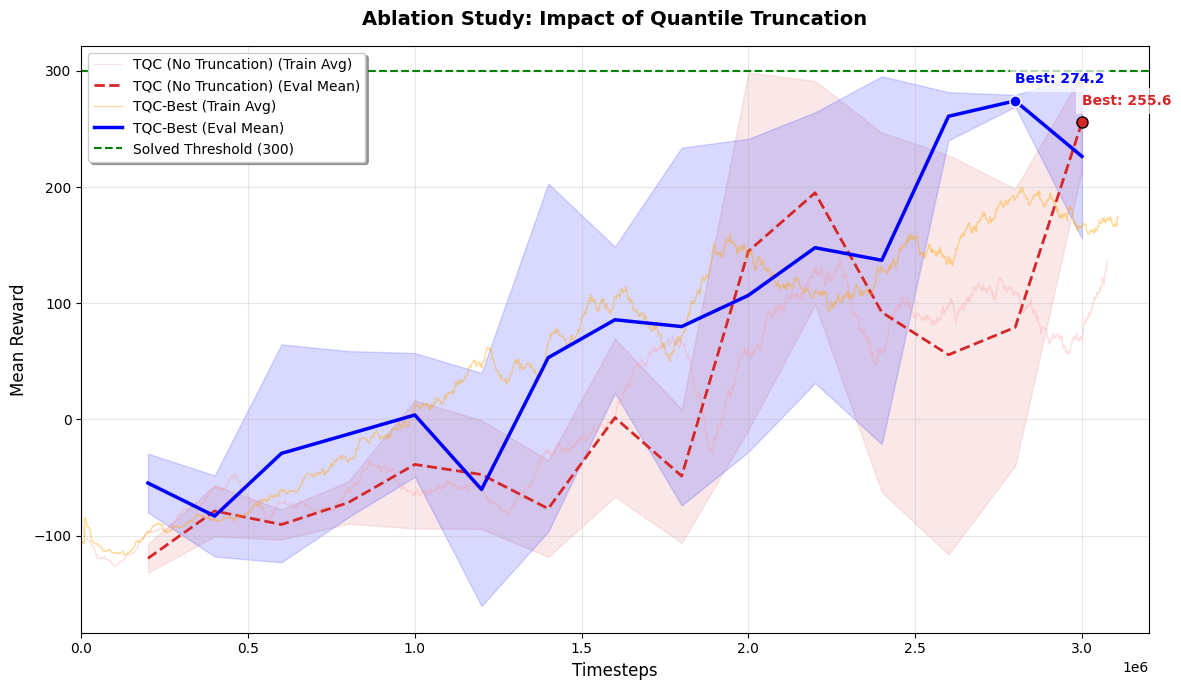

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# CORRECT FOLDER NAMES
# Baseline: Original successful run (0-3M steps)
EXP_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928"
# Ablation: No Truncation (From your screenshot)
EXP_ABLATION = "tqc_v3_ablation_no_truncation_3M_20251228_1458"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA (Orange/Pink Lines)
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            train_df['l_cumsum'] = train_df['l'].cumsum()
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA (Blue/Red Lines)
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red) ---
    if abl_data['train'] is not None:
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{abl_name} (Eval Mean)")
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

        # Pinpoint Ablation Best
        best_abl_idx = np.argmax(abl_data['eval_mean'])
        best_abl_x = abl_data['eval_timesteps'][best_abl_idx]
        best_abl_y = abl_data['eval_mean'][best_abl_idx]

        plt.plot(best_abl_x, best_abl_y, 'o', color='#d62728', markersize=8, markeredgecolor='black')
        plt.annotate(f"Best: {best_abl_y:.1f}",
                     xy=(best_abl_x, best_abl_y),
                     xytext=(best_abl_x, best_abl_y + 15),
                     color='#d62728', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- PLOT BASELINE (Blue) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # Pinpoint Baseline Best
        best_base_idx = np.argmax(base_data['eval_mean'])
        best_base_x = base_data['eval_timesteps'][best_base_idx]
        best_base_y = base_data['eval_mean'][best_base_idx]

        plt.plot(best_base_x, best_base_y, 'o', color='blue', markersize=8, markeredgecolor='white')
        plt.annotate(f"Best: {best_base_y:.1f}",
                     xy=(best_base_x, best_base_y),
                     xytext=(best_base_x, best_base_y + 15),
                     color='blue', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_tqc_no_truncation_ablation_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    ablation_data = load_experiment_data(EXP_ABLATION)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, ablation_data,
                        "TQC-Best", "TQC (No Truncation)",
                        "Ablation Study: Impact of Quantile Truncation")

--- LOADING DATA ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- GENERATING GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_ppo_capacity_ablation_pro.png


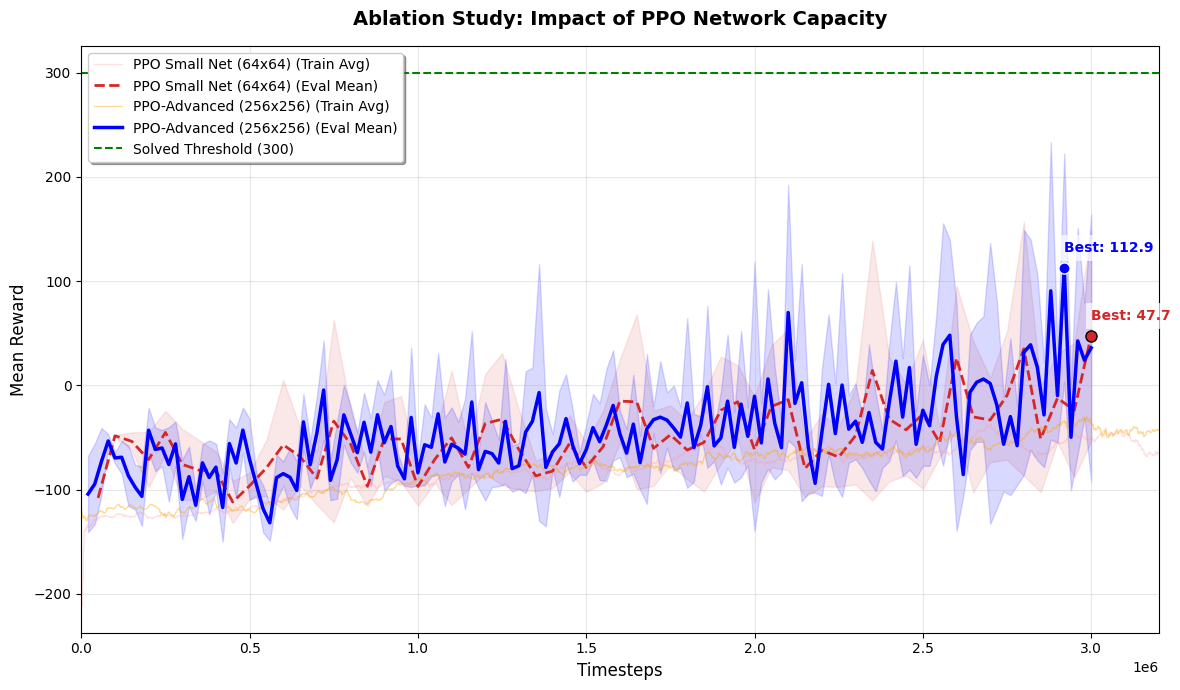

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# CORRECT FOLDER NAMES (From your screenshots)
# Baseline: The SOTA PPO run (256x256)
EXP_BASELINE = "sota_ppo_v3_1_hardcore"
# Ablation: The Small Network run (64x64)
EXP_ABLATION = "ppo_advanced_ablation_small_net"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA (Orange/Pink Lines)
    # Recursive search to find logs deep in PPO_1/train/ etc.
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            # Calculate cumulative steps
            train_df['l_cumsum'] = train_df['l'].cumsum()

            # Smoothing (100-episode window)
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M steps
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA (Blue/Red Lines)
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            # Load the first found npz file
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red) ---
    if abl_data['train'] is not None:
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{abl_name} (Eval Mean)")
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

        # Pinpoint Ablation Best
        best_abl_idx = np.argmax(abl_data['eval_mean'])
        best_abl_x = abl_data['eval_timesteps'][best_abl_idx]
        best_abl_y = abl_data['eval_mean'][best_abl_idx]

        plt.plot(best_abl_x, best_abl_y, 'o', color='#d62728', markersize=8, markeredgecolor='black')
        plt.annotate(f"Best: {best_abl_y:.1f}",
                     xy=(best_abl_x, best_abl_y),
                     xytext=(best_abl_x, best_abl_y + 15),
                     color='#d62728', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- PLOT BASELINE (Blue) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # Pinpoint Baseline Best
        best_base_idx = np.argmax(base_data['eval_mean'])
        best_base_x = base_data['eval_timesteps'][best_base_idx]
        best_base_y = base_data['eval_mean'][best_base_idx]

        plt.plot(best_base_x, best_base_y, 'o', color='blue', markersize=8, markeredgecolor='white')
        plt.annotate(f"Best: {best_base_y:.1f}",
                     xy=(best_base_x, best_base_y),
                     xytext=(best_base_x, best_base_y + 15),
                     color='blue', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_ppo_capacity_ablation_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    ablation_data = load_experiment_data(EXP_ABLATION)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, ablation_data,
                        "PPO-Advanced (256x256)", "PPO Small Net (64x64)",
                        "Ablation Study: Impact of PPO Network Capacity")

--- LOADING DATA ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- GENERATING GRAPH ---
Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_ppo_decoupling_ablation_pro.png


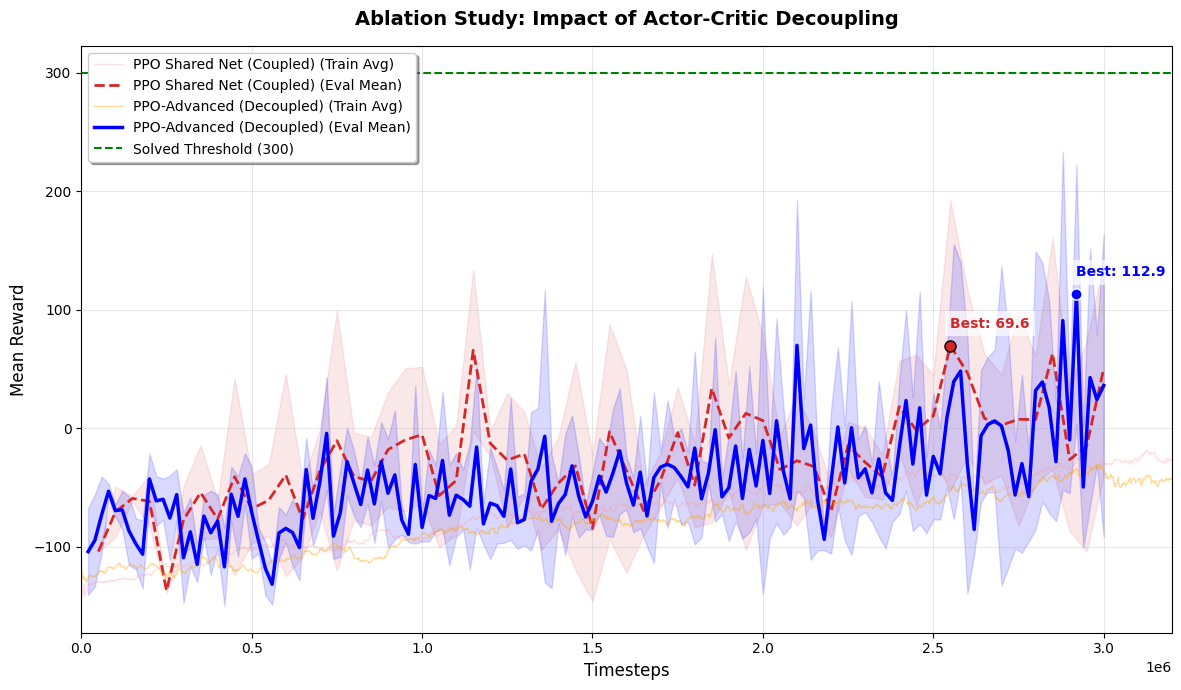

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# CORRECT FOLDER NAMES
# Baseline: The SOTA PPO run (Decoupled)
EXP_BASELINE = "sota_ppo_v3_1_hardcore"
# Ablation: The Shared Network run (Coupled)
EXP_ABLATION = "ppo_advanced_ablation_shared_net"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            train_df['l_cumsum'] = train_df['l'].cumsum()
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red) ---
    if abl_data['train'] is not None:
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{abl_name} (Eval Mean)")
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

        # Pinpoint Ablation Best
        best_abl_idx = np.argmax(abl_data['eval_mean'])
        best_abl_x = abl_data['eval_timesteps'][best_abl_idx]
        best_abl_y = abl_data['eval_mean'][best_abl_idx]

        plt.plot(best_abl_x, best_abl_y, 'o', color='#d62728', markersize=8, markeredgecolor='black')
        plt.annotate(f"Best: {best_abl_y:.1f}",
                     xy=(best_abl_x, best_abl_y),
                     xytext=(best_abl_x, best_abl_y + 15),
                     color='#d62728', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- PLOT BASELINE (Blue) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # Pinpoint Baseline Best
        best_base_idx = np.argmax(base_data['eval_mean'])
        best_base_x = base_data['eval_timesteps'][best_base_idx]
        best_base_y = base_data['eval_mean'][best_base_idx]

        plt.plot(best_base_x, best_base_y, 'o', color='blue', markersize=8, markeredgecolor='white')
        plt.annotate(f"Best: {best_base_y:.1f}",
                     xy=(best_base_x, best_base_y),
                     xytext=(best_base_x, best_base_y + 15),
                     color='blue', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_ppo_decoupling_ablation_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    ablation_data = load_experiment_data(EXP_ABLATION)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, ablation_data,
                        "PPO-Advanced (Decoupled)", "PPO Shared Net (Coupled)",
                        "Ablation Study: Impact of Actor-Critic Decoupling")

--- LOADING DATA ---

--- GENERATING GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_ppo_baseline_vs_tuned_pro.png


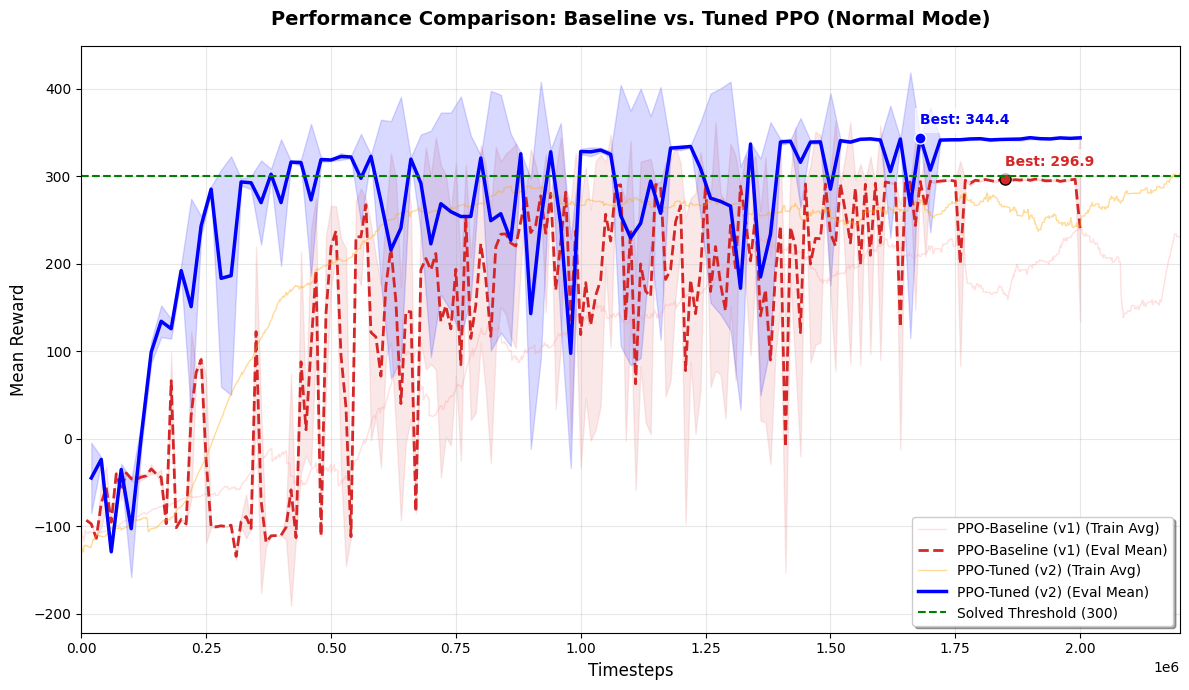

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# CORRECT FOLDER NAMES (From your screenshot)
# Baseline: The initial basic PPO
EXP_BASELINE = "improved_ppo_v2" # This is the "Better" one (Blue Line)
# Comparison: The basic PPO
EXP_COMPARISON = "basic_ppo_final" # This is the "Worse" one (Red Line)

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA
    # Recursive search to find logs deep in subfolders
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            # Calculate cumulative steps
            train_df['l_cumsum'] = train_df['l'].cumsum()

            # Smoothing (100-episode window)
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 2.2M steps (Since these were likely 2M runs)
            data['train'] = train_df[train_df['l_cumsum'] <= 2200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            # Load the first found npz file
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION ---
def plot_pro_comparison(base_data, comp_data, base_name, comp_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT COMPARISON (Red - Basic PPO) ---
    if comp_data['train'] is not None:
        plt.plot(comp_data['train']['l_cumsum'], comp_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{comp_name} (Train Avg)")

    if comp_data['eval_timesteps'] is not None:
        plt.plot(comp_data['eval_timesteps'], comp_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{comp_name} (Eval Mean)")
        plt.fill_between(comp_data['eval_timesteps'],
                         comp_data['eval_mean'] - comp_data['eval_std'],
                         comp_data['eval_mean'] + comp_data['eval_std'],
                         color='#d62728', alpha=0.1)

        # Pinpoint Best for Basic PPO
        best_comp_idx = np.argmax(comp_data['eval_mean'])
        best_comp_x = comp_data['eval_timesteps'][best_comp_idx]
        best_comp_y = comp_data['eval_mean'][best_comp_idx]

        plt.plot(best_comp_x, best_comp_y, 'o', color='#d62728', markersize=8, markeredgecolor='black')
        plt.annotate(f"Best: {best_comp_y:.1f}",
                     xy=(best_comp_x, best_comp_y),
                     xytext=(best_comp_x, best_comp_y + 15),
                     color='#d62728', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- PLOT BASELINE (Blue - Improved PPO) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # Pinpoint Best for Improved PPO
        best_base_idx = np.argmax(base_data['eval_mean'])
        best_base_x = base_data['eval_timesteps'][best_base_idx]
        best_base_y = base_data['eval_mean'][best_base_idx]

        plt.plot(best_base_x, best_base_y, 'o', color='blue', markersize=8, markeredgecolor='white')
        plt.annotate(f"Best: {best_base_y:.1f}",
                     xy=(best_base_x, best_base_y),
                     xytext=(best_base_x, best_base_y + 15),
                     color='blue', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- FORMATTING ---
    # Note: Normal difficulty solve threshold is usually 300 as well
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right', frameon=True, shadow=True)
    plt.xlim(0, 2200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_ppo_baseline_vs_tuned_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    comparison_data = load_experiment_data(EXP_COMPARISON)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, comparison_data,
                        "PPO-Tuned (v2)", "PPO-Baseline (v1)",
                        "Performance Comparison: Baseline vs. Tuned PPO (Normal Mode)")

--- GENERATING GRAND SUMMARY GRAPH ---
Loading PPO-Tuned (v2)...
Loading PPO-Adv (gSDE)...
Loading PPO-Advanced...
Loading TQC-Best (0-3M)...
Loading TQC-Resume (3M+)...

Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_grand_summary_comparison.png


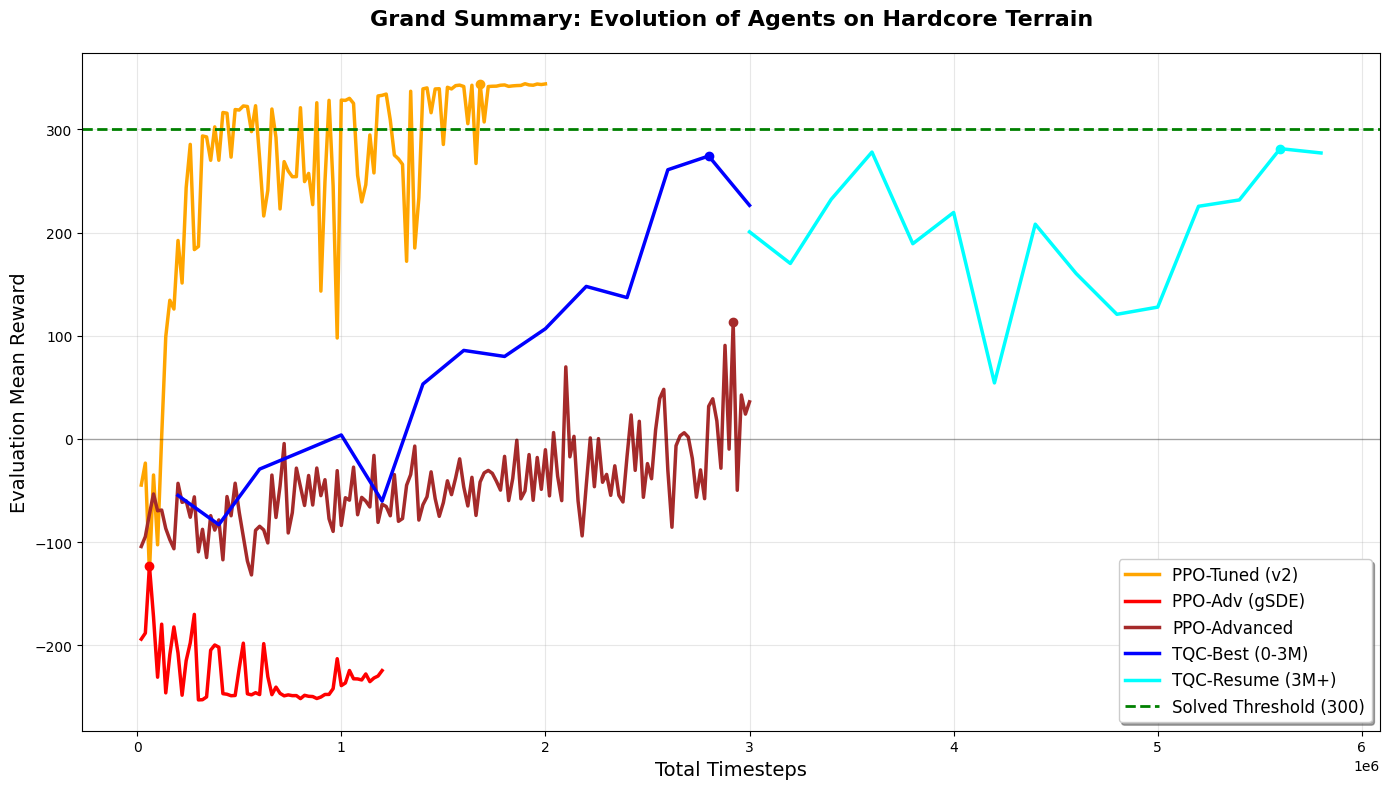

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# DICTIONARY OF EXPERIMENTS
# Format: "Display Name": "Folder Name"
experiments = {
    "PPO-Tuned (v2)": "improved_ppo_v2",
    "PPO-Adv (gSDE)": "sota_ppo_v3_hardcore",
    "PPO-Advanced":   "sota_ppo_v3_1_hardcore",
    "TQC-Best (0-3M)": "tqc_v3_hardcore_rerun_20251227_1928",
    "TQC-Resume (3M+)": "tqc_v3_hardcore_rerun_20251227_1928_resume_3M"
}

# Define colors for distinct visualization
colors = {
    "PPO-Tuned (v2)": "orange",
    "PPO-Adv (gSDE)": "red",
    "PPO-Advanced":   "brown",
    "TQC-Best (0-3M)": "blue",
    "TQC-Resume (3M+)": "cyan"
}

# --- DATA LOADING FUNCTION ---
def load_eval_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)

    # Recursive search for evaluations.npz
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            # Use the first one found
            eval_data = np.load(eval_files[0])
            timesteps = eval_data['timesteps']
            mean_reward = np.mean(eval_data['results'], axis=1)
            return timesteps, mean_reward
        except:
            return None, None
    else:
        return None, None

# --- PLOTTING FUNCTION ---
def plot_grand_summary(experiments):
    plt.figure(figsize=(14, 8))

    for display_name, folder_name in experiments.items():
        print(f"Loading {display_name}...")
        x, y = load_eval_data(folder_name)

        if x is not None and y is not None:
            # SPECIAL HANDLING FOR RESUME
            # If TQC-Resume starts at 0 in the logs, we shift it to start at 3M
            if "Resume" in display_name and x[0] < 2000000:
                x = x + 3000000

            plt.plot(x, y, label=display_name, color=colors.get(display_name, 'gray'), linewidth=2.5)

            # Mark the max point
            max_idx = np.argmax(y)
            plt.plot(x[max_idx], y[max_idx], 'o', color=colors.get(display_name, 'gray'))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=2, label="Solved Threshold (300)")
    plt.axhline(y=0, color='black', linewidth=1, alpha=0.3)

    plt.title("Grand Summary: Evolution of Agents on Hardcore Terrain", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Total Timesteps", fontsize=14)
    plt.ylabel("Evaluation Mean Reward", fontsize=14)
    plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True, fancybox=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_grand_summary_comparison.png"
    plt.savefig(save_path, dpi=150)
    print(f"\nGraph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- GENERATING GRAND SUMMARY GRAPH ---")
plot_grand_summary(experiments)

--- GENERATING GRAND SUMMARY GRAPH ---
Loading PPO-Tuned (v2)...
Loading PPO-Adv (gSDE)...
Loading PPO-Advanced...
Loading TQC-Best (0-3M)...
Loading TQC-Resume (3M+)...

Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_grand_summary_comparison_pro.png


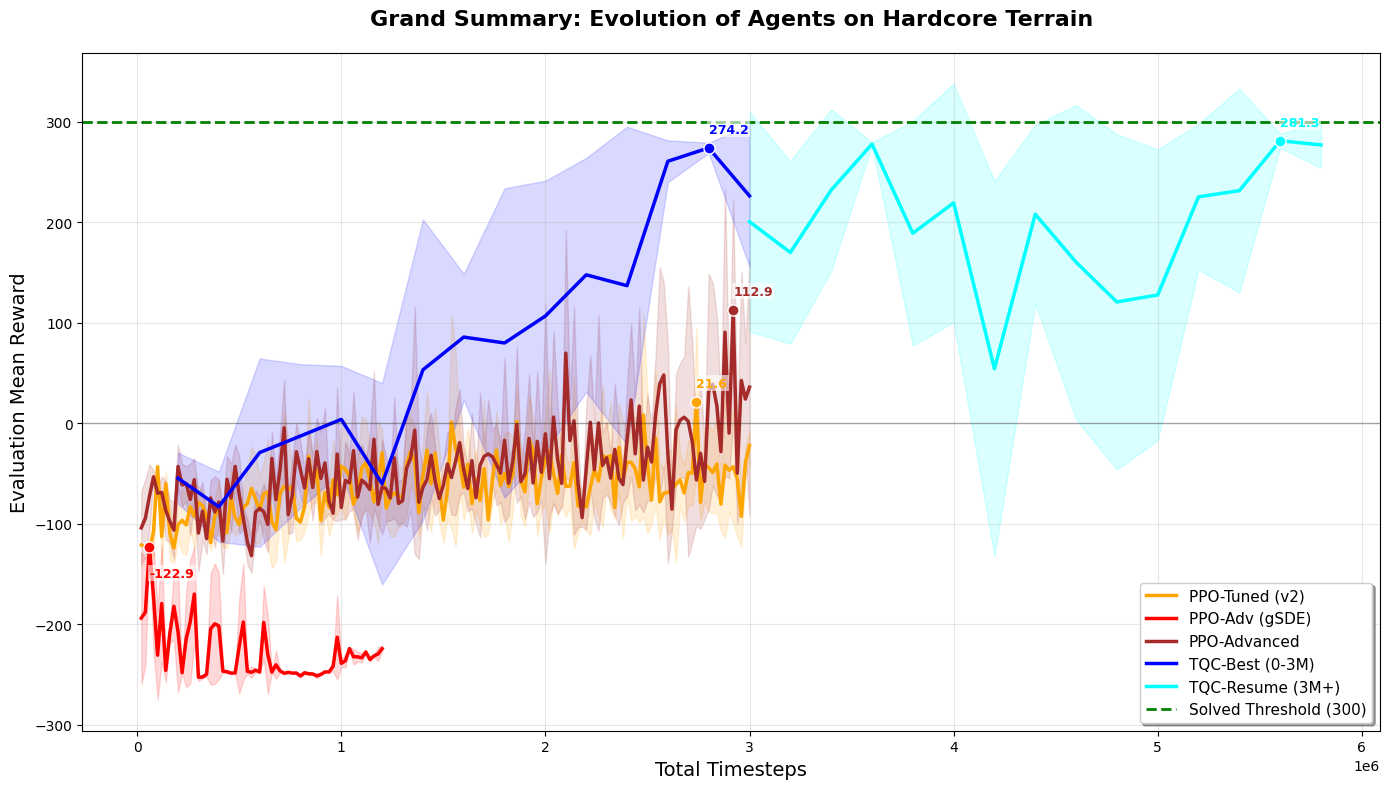

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# CORRECTED DICTIONARY OF EXPERIMENTS
# Keys = Label on Graph, Values = Folder Name
experiments = {
    "PPO-Tuned (v2)":   "improved_ppo_v2_hardcore",        # Fixed Name
    "PPO-Adv (gSDE)":   "sota_ppo_v3_hardcore",
    "PPO-Advanced":     "sota_ppo_v3_1_hardcore",
    "TQC-Best (0-3M)":  "tqc_v3_hardcore_rerun_20251227_1928",
    "TQC-Resume (3M+)": "tqc_v3_hardcore_rerun_20251227_1928_resume_3M"
}

# Colors for distinct visualization
colors = {
    "PPO-Tuned (v2)":   "orange",
    "PPO-Adv (gSDE)":   "red",
    "PPO-Advanced":     "brown",
    "TQC-Best (0-3M)":  "blue",
    "TQC-Resume (3M+)": "cyan"
}

# --- DATA LOADING FUNCTION (Now returns STD) ---
def load_eval_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)

    # Recursive search for evaluations.npz
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            # Use the first one found
            eval_data = np.load(eval_files[0])
            timesteps = eval_data['timesteps']
            mean_reward = np.mean(eval_data['results'], axis=1)
            std_reward = np.std(eval_data['results'], axis=1)
            return timesteps, mean_reward, std_reward
        except:
            return None, None, None
    else:
        return None, None, None

# --- PLOTTING FUNCTION ---
def plot_grand_summary(experiments):
    plt.figure(figsize=(14, 8))

    for display_name, folder_name in experiments.items():
        print(f"Loading {display_name}...")
        x, y, y_std = load_eval_data(folder_name)

        if x is not None and y is not None:
            # Shift TQC-Resume timestamps if needed
            if "Resume" in display_name and x[0] < 2000000:
                x = x + 3000000

            color = colors.get(display_name, 'gray')

            # 1. Plot Mean Line
            plt.plot(x, y, label=display_name, color=color, linewidth=2.5)

            # 2. Add Shaded Variance (Standard Deviation)
            plt.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

            # 3. Pinpoint Best Reward for EACH curve
            max_idx = np.argmax(y)
            best_x = x[max_idx]
            best_y = y[max_idx]

            plt.plot(best_x, best_y, 'o', color=color, markeredgecolor='white', markersize=8)

            # Offset the text slightly to avoid overlapping
            offset_y = 15 if best_y > 0 else -30

            plt.annotate(f"{best_y:.1f}",
                         xy=(best_x, best_y),
                         xytext=(best_x, best_y + offset_y),
                         color=color, fontweight='bold', fontsize=9,
                         bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=1))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=2, label="Solved Threshold (300)")
    plt.axhline(y=0, color='black', linewidth=1, alpha=0.3)

    plt.title("Grand Summary: Evolution of Agents on Hardcore Terrain", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel("Total Timesteps", fontsize=14)
    plt.ylabel("Evaluation Mean Reward", fontsize=14)
    plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True, fancybox=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_grand_summary_comparison_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"\nGraph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- GENERATING GRAND SUMMARY GRAPH ---")
plot_grand_summary(experiments)

In [23]:
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# The dictionary of agents you want to check
# Format: "Display Name": "Folder Name"
agents = {
    # NORMAL DIFFICULTY
    "PPO-Baseline (Normal)": "basic_ppo_final",
    "PPO-Tuned (Normal)":    "improved_ppo_v2",

    # HARDCORE DIFFICULTY
    "PPO-Tuned (Hardcore)":  "improved_ppo_v2_hardcore",
    "PPO-Adv (gSDE)":        "sota_ppo_v3_hardcore",
    "PPO-Advanced":          "sota_ppo_v3_1_hardcore",
    "TQC-Best (0-3M)":       "tqc_v3_hardcore_rerun_20251227_1928",
    "TQC-Resume (3M+)":      "tqc_v3_hardcore_rerun_20251227_1928_resume_3M"
}

print(f"{'AGENT NAME':<25} | {'BEST MEAN':<10} | {'STD DEV':<10} | {'TIMESTEP':<10}")
print("-" * 65)

for display_name, folder_name in agents.items():
    full_path = os.path.join(BASE_PATH, folder_name)

    # Find evaluations.npz recursively
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            data = np.load(eval_files[0])
            results = data['results']   # Shape: (n_evaluations, n_episodes)
            timesteps = data['timesteps']

            # Calculate mean across episodes for each evaluation step
            means = np.mean(results, axis=1)
            stds = np.std(results, axis=1)

            # Find the index of the best mean reward
            best_idx = np.argmax(means)

            best_mean = means[best_idx]
            best_std = stds[best_idx]
            best_step = timesteps[best_idx]

            # Adjust timestep for Resume run (visual fix only)
            if "Resume" in display_name:
                best_step += 3000000

            print(f"{display_name:<25} | {best_mean:<10.1f} | ±{best_std:<9.1f} | {int(best_step):<10}")

        except Exception as e:
            print(f"{display_name:<25} | {'Error':<10} | {'-':<10} | {'-'}")
    else:
        print(f"{display_name:<25} | {'No Data':<10} | {'-':<10} | {'-'}")

AGENT NAME                | BEST MEAN  | STD DEV    | TIMESTEP  
-----------------------------------------------------------------
PPO-Baseline (Normal)     | 296.9      | ±1.4       | 1850000   
PPO-Tuned (Normal)        | 344.4      | ±0.9       | 1680000   
PPO-Tuned (Hardcore)      | 21.6       | ±73.7      | 2740000   
PPO-Adv (gSDE)            | -122.9     | ±1.0       | 60000     
PPO-Advanced              | 112.9      | ±109.4     | 2920000   
TQC-Best (0-3M)           | 274.2      | ±5.1       | 2800000   
TQC-Resume (3M+)          | 281.3      | ±6.9       | 8600000   


--- LOADING DATA ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- GENERATING GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_ppo_gsde_vs_standard_pro.png


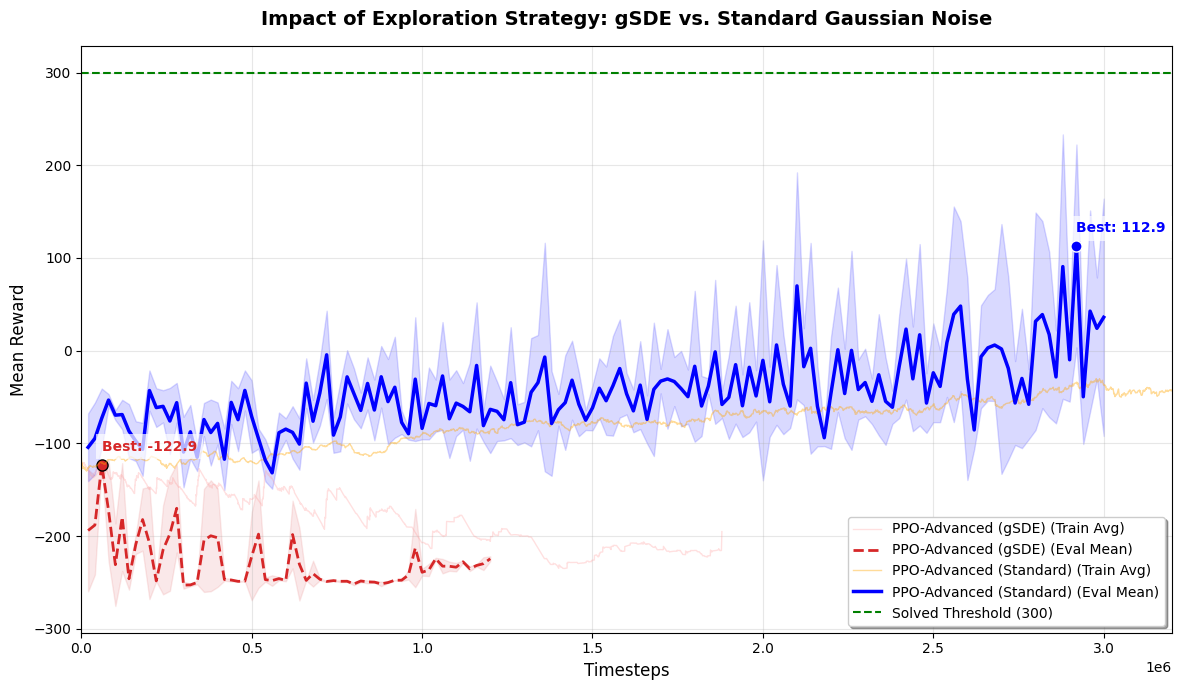

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# CORRECT FOLDER NAMES (Based on your file history)
# Baseline: The "Good" PPO (No gSDE, score ~112)
EXP_BASELINE = "sota_ppo_v3_1_hardcore"
# Comparison: The "Bad" PPO (With gSDE, score ~ -122)
EXP_COMPARISON = "sota_ppo_v3_hardcore"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            train_df['l_cumsum'] = train_df['l'].cumsum()
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION ---
def plot_pro_comparison(base_data, comp_data, base_name, comp_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT COMPARISON (Red - gSDE) ---
    if comp_data['train'] is not None:
        plt.plot(comp_data['train']['l_cumsum'], comp_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{comp_name} (Train Avg)")

    if comp_data['eval_timesteps'] is not None:
        plt.plot(comp_data['eval_timesteps'], comp_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{comp_name} (Eval Mean)")
        plt.fill_between(comp_data['eval_timesteps'],
                         comp_data['eval_mean'] - comp_data['eval_std'],
                         comp_data['eval_mean'] + comp_data['eval_std'],
                         color='#d62728', alpha=0.1)

        # Pinpoint Best for gSDE
        best_comp_idx = np.argmax(comp_data['eval_mean'])
        best_comp_x = comp_data['eval_timesteps'][best_comp_idx]
        best_comp_y = comp_data['eval_mean'][best_comp_idx]

        plt.plot(best_comp_x, best_comp_y, 'o', color='#d62728', markersize=8, markeredgecolor='black')
        plt.annotate(f"Best: {best_comp_y:.1f}",
                     xy=(best_comp_x, best_comp_y),
                     xytext=(best_comp_x, best_comp_y + 15),
                     color='#d62728', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- PLOT BASELINE (Blue - Standard PPO-Adv) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # Pinpoint Best for Standard
        best_base_idx = np.argmax(base_data['eval_mean'])
        best_base_x = base_data['eval_timesteps'][best_base_idx]
        best_base_y = base_data['eval_mean'][best_base_idx]

        plt.plot(best_base_x, best_base_y, 'o', color='blue', markersize=8, markeredgecolor='white')
        plt.annotate(f"Best: {best_base_y:.1f}",
                     xy=(best_base_x, best_base_y),
                     xytext=(best_base_x, best_base_y + 15),
                     color='blue', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='lower right', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_ppo_gsde_vs_standard_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    comparison_data = load_experiment_data(EXP_COMPARISON)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, comparison_data,
                        "PPO-Advanced (Standard)", "PPO-Advanced (gSDE)",
                        "Impact of Exploration Strategy: gSDE vs. Standard Gaussian Noise")